# 📊 Proyecto Final: Rendimiento de Establecimientos de Salud (2005-2022)

**Autores:** Valentina Falco, Lorena Flores


Este trabajo analiza cómo funcionaron los hospitales de la Provincia de Buenos Aires entre 2005 y 2022, el detalle del rendimiento de los establecimientos teniendo en cuenta la información de: cantidad de consultas odontológicas, médicas y paramédicas, interconsultas, egresos, camas disponibles, días de estadía, etc. A partir de datos oficiales, se observa el rendimiento de distintos centros de salud en cada municipio y región sanitaria. El objetivo es entender mejor cómo evolucionó el sistema hospitalario en ese período,  identificar patrones, analizar diferencias entre zonas y analizar posibles mejoras a futuro.

Dataset: https://catalogo.datos.gba.gob.ar/th/dataset/rendimientos-establecimientos-salud/archivo/8c3130cb-61ad-4014-b829-503b214ba3c0

Información detallada de las columnas: https://catalogo.datos.gba.gob.ar/dataset/219d6b32-2e34-40cb-913d-b05c47cab75f/resource/52d5fc8d-75a1-4e63-853d-92f8e938e584/download/definiciones-rendimientos-hospitalarios.pdf

El objetivo es analizar la distribución de ingresos, egresos y consultas médicas para conocer el volumen y características de la atención brindada. Calcular indicadores hospitalarios relevantes, como el porcentaje de ocupación de camas, el promedio de días de estadía, el giro de camas y la tasa de mortalidad hospitalaria, que permiten evaluar la eficiencia y calidad del servicio prestado. Detectar posibles desequilibrios entre la cantidad de camas disponibles y la demanda de internación, considerando factores como la estacionalidad anual o la capacidad instalada. Visualizar y modelar tendencias en la evolución de la internación y la ocupación de camas a lo largo del tiempo, lo cual podría contribuir a la planificación y optimización de recursos. Comparar el comportamiento entre distintos servicios médicos y paramédicos, para evaluar la carga asistencial de cada uno y proponer mejoras si fuese necesario.

## 🔍 ¿Qué es el Aprendizaje Supervisado?

El aprendizaje supervisado es una técnica de la inteligencia artificial en la cual se entrena un modelo a partir de un conjunto de datos etiquetados, es decir, datos donde la variable objetivo ya se conoce.

En este proyecto, utilizamos **modelos de clasificación** para predecir el nivel de rendimiento de los hospitales.


## ⚙️ Ajuste del Modelo

Entrenamos un modelo de clasificación basado en **Random Forest**, el cual permite manejar grandes cantidades de datos y variables, siendo robusto frente a valores atípicos y sobreajuste.

Se utilizó la función `train_test_split` para dividir los datos y evaluar el rendimiento del modelo sobre datos que no ha visto.


## 📈 Evaluación del Modelo

Se utilizó un **informe de clasificación (classification report)** y la **matriz de confusión** para evaluar el desempeño del modelo.

Estas métricas permiten analizar la precisión, la sensibilidad (recall), la exactitud y la puntuación F1 del modelo.


## 📚 Preparación del entorno

### 📂 Importación de herramientas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, mean_absolute_error, roc_curve, roc_auc_score, ConfusionMatrixDisplay
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
#from google.colab import files

## ⚙️ Preprocesamiento de Datos

#### 🔹 Porcentaje de filas con al menos un valor nulo

##### Explicación:

- archivo.isnull() crea un DataFrame booleano indicando dónde hay valores nulos.

- any(axis=1) verifica si alguna columna en cada fila tiene un valor nulo (devuelve True o False por fila).

- mean() calcula la proporción de filas que contienen al menos un nulo (True se interpreta como 1, False como 0).

- Multiplicamos por 100 para obtener el porcentaje.

##### Resultado:
Este valor indica el porcentaje de filas del dataset que contienen al menos un valor faltante.

In [3]:
url = 'https://raw.githubusercontent.com/valentinafalco/ProyectoFinal-DS-YPF/refs/heads/main/2da%20Entrega/rendimientos-hospitalarios_2005-2022.csv'
df = pd.read_csv(url, sep=';', on_bad_lines='skip')
df.head()

,anio,region_sanitaria,municipio_id,municipio_nombre,establecimiento_id,establecimiento_nombre,dependencia,consultas_odontologicas,consultas_medicas,consultas_paramedicas,...,egresos,dias_camas_disponible,promedio_camas_disponibles,pacientes_dias,porcentaje_ocupacion,dias_estadia,promedio_dias_estadia,defunciones,giro_de_camas,tasa_mortalidad_hospitalaria
0,2005,I,60007,Adolfo Alsina,NaN,Hospital Local General José de San Martín,Municipal,6424.0,94401.0,18888.0,...,1474.0,10963.0,30.0,4798.0,44.0,4529.0,3.0,42.0,49.0,3.0
1,2005,I,60007,Adolfo Alsina,NaN,Hospital Dr. Noe Yarcho,Municipal,4493.0,18370.0,4459.0,...,471.0,10950.0,30.0,2184.0,20.0,2027.0,4.0,20.0,16.0,4.0
2,2005,I,60007,Adolfo Alsina,NaN,Hogar de Ancianos General N. Levalle,Municipal,0.0,0.0,0.0,...,2.0,12740.0,35.0,11371.0,89.0,848.0,424.0,1.0,0.0,50.0
3,2005,I,60007,Adolfo Alsina,NaN,Hospital Demetrio Carmelo Loyarte,Municipal,0.0,2024.0,846.0,...,120.0,6570.0,18.0,278.0,4.0,279.0,2.0,1.0,7.0,1.0
4,2005,I,60007,Adolfo Alsina,NaN,Unidad Sanitaria San Miguel Arcangel,Municipal,3086.0,2196.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
# Porcentaje de filas con al menos un nulodf
df.isnull().any(axis=1).mean() * 100

np.float64(98.99469135485856)


Significa que el 99% del dataset tiene al menos un valor faltante (nulo). Eliminar todas esas filas sería un error, porque nos quedaríamos solo con el 1% de los datos.

Revisamos cuántos valores nulos tiene cada columna y tomamos una decision

In [5]:
faltantes = df.isnull().sum()
print("Valores faltantes: \n", faltantes)

Valores faltantes: 
 anio                                0
region_sanitaria                    0
municipio_id                        0
municipio_nombre                    0
establecimiento_id              27522
establecimiento_nombre              0
dependencia                         0
consultas_odontologicas          5590
consultas_medicas                1039
consultas_paramedicas            3031
interconsultas                  10997
egresos                          9546
dias_camas_disponible            9535
promedio_camas_disponibles       9535
pacientes_dias                   9474
porcentaje_ocupacion             9540
dias_estadia                     9568
promedio_dias_estadia            9663
defunciones                      9591
giro_de_camas                    9567
tasa_mortalidad_hospitalaria     9663
dtype: int64


#### 🔹 Rellenar valores faltantes inteligentemente

Cuando encontramos datos faltantes, es importante imputarlos de manera que no distorsionen el análisis. La estrategia depende del tipo de variable y su distribución:

##### 🟦 Variables numéricas (por ejemplo: `egresos`, `dias_camas_disponible`, `defunciones`, etc.)

- **Si la variable tiene una distribución sesgada** (es decir, muchos valores extremos o asimetría en los datos), es mejor usar la **mediana** para rellenar los valores faltantes.  
  La mediana representa el valor central y no se ve afectada por valores extremos, evitando así sesgar la imputación.

- **Si la variable tiene una distribución aproximadamente simétrica**, se puede usar la **media** para imputar.  
  La media es el promedio y funciona bien cuando los datos no tienen valores atípicos fuertes.

- **En algunos casos específicos**, si el valor 0 representa la ausencia de un evento (por ejemplo, "0 egresos" podría indicar que no hubo egresos), se puede rellenar con 0.  
  Esto debe hacerse solo cuando tiene sentido desde el punto de vista del negocio o dominio de los datos.


Esta estrategia busca mantener la integridad de los datos y minimizar el impacto de los valores faltantes en el análisis.


In [6]:
columnas_numericas = [
    'consultas_odontologicas', 'consultas_medicas', 'consultas_paramedicas',
    'interconsultas', 'egresos', 'dias_camas_disponible', 'promedio_camas_disponibles',
    'pacientes_dias', 'porcentaje_ocupacion', 'dias_estadia', 
    'promedio_dias_estadia', 'defunciones', 'giro_de_camas', 'tasa_mortalidad_hospitalaria'
]

df[columnas_numericas].skew().sort_values()

tasa_mortalidad_hospitalaria     7.348261
defunciones                      7.942451
promedio_camas_disponibles       9.638751
dias_camas_disponible            9.665125
consultas_medicas               10.113048
giro_de_camas                   11.319577
pacientes_dias                  11.426462
egresos                         11.861566
consultas_paramedicas           12.386282
interconsultas                  12.668978
dias_estadia                    14.628040
promedio_dias_estadia           15.044635
porcentaje_ocupacion            20.299912
consultas_odontologicas         21.461145
dtype: float64

#### ✅ Interpretación rápida

###### ✔️ **Distribución aproximadamente simétrica** (skew entre -0.5 y 0.5):

Ninguna de tus columnas está en este rango → ninguna tiene simetría ideal.

##### ⚠️ **Moderadamente sesgada** (skew entre ±0.5 y ±1):

- `tasa_mortalidad_hospitalaria` → 7.34  
- `defunciones` → 7.94  
  → _Ya están bastante más allá del límite: son muy sesgadas, en realidad_.

##### ❗ **Altamente sesgada** (skew > 1 o < -1):

| Variable                     | Skew  | ¿Sesgada?        | ¿Qué usar?  |
|------------------------------|-------|------------------|-------------|
| `tasa_mortalidad_hospitalaria` | 7.35  | Sí, fuertemente  | **mediana** |
| `defunciones`                 | 7.94  | Sí, fuertemente  | **mediana** |
| `promedio_camas_disponibles`  | 9.64  | Sí               | **mediana** |
| `dias_camas_disponible`       | 9.66  | Sí               | **mediana** |
| `consultas_medicas`           | 10.11 | Sí               | **mediana** |
| `giro_de_camas`               | 11.31 | Sí               | **mediana** |
| `pacientes_dias`              | 11.43 | Sí               | **mediana** |
| `egresos`                    | 11.86 | Sí               | **mediana** |
| `consultas_paramedicas`       | 12.39 | Sí               | **mediana** |
| `interconsultas`              | 12.67 | Sí               | **mediana** |
| `dias_estadia`                | 14.63 | Sí               | **mediana** |
| `promedio_dias_estadia`       | 15.04 | Sí               | **mediana** |
| `porcentaje_ocupacion`        | 20.30 | Sí               | **mediana** |
| `consultas_odontologicas`     | 21.46 | Sí               | **mediana** |

##### ✅ Conclusión:

> 💡 **Todas las variables tienen una distribución altamente sesgada**.  
> 👉 Por lo tanto, **conviene imputar los nulos con la _mediana_ y no con la media**, porque la media estaría distorsionada por los valores extremos.

In [8]:
# Seleccionar solo columnas numéricas
columnas_numericas = df.select_dtypes(include=['number']).columns

# Calcular el % de valores nulos SOLO en columnas numéricas
null_percent = df[columnas_numericas].isnull().mean() * 100

# Categorías de columnas según % de nulos
menos_10 = null_percent[null_percent < 10].index
entre_10_15 = null_percent[(null_percent >= 10) & (null_percent <= 15)].index
mas_15 = null_percent[null_percent > 15].index

# 1. Rellenar con la media las columnas numéricas con menos del 10% de nulos
df[menos_10] = df[menos_10].fillna(df[menos_10].mean())

# 2. Rellenar con la mediana las columnas numéricas con entre 10% y 15% de nulos
df[entre_10_15] = df[entre_10_15].fillna(df[entre_10_15].median())

# 3. Mostrar columnas numéricas con más del 15% de nulos (sin modificarlas)
print("\n❗ Columnas numéricas con más del 15% de valores nulos:")
for col in mas_15:
    print(f"- {col}: {null_percent[col]:.2f}% nulos")

# Verificación general de columnas numéricas
print("\n✅ Porcentaje de nulos después de rellenar (solo numéricas):")
print(df[columnas_numericas].isnull().mean() * 100)


❗ Columnas numéricas con más del 15% de valores nulos:
- establecimiento_id: 70.58% nulos
- interconsultas: 28.20% nulos
- egresos: 24.48% nulos
- dias_camas_disponible: 24.45% nulos
- promedio_camas_disponibles: 24.45% nulos
- pacientes_dias: 24.30% nulos
- porcentaje_ocupacion: 24.47% nulos
- dias_estadia: 24.54% nulos
- promedio_dias_estadia: 24.78% nulos
- defunciones: 24.60% nulos
- giro_de_camas: 24.54% nulos
- tasa_mortalidad_hospitalaria: 24.78% nulos

✅ Porcentaje de nulos después de rellenar (solo numéricas):
anio                             0.000000
municipio_id                     0.000000
establecimiento_id              70.581899
consultas_odontologicas          0.000000
consultas_medicas                0.000000
consultas_paramedicas            0.000000
interconsultas                  28.202498
egresos                         24.481317
dias_camas_disponible           24.453107
promedio_camas_disponibles      24.453107
pacientes_dias                  24.296669
porcentaje_o

#### Decisión para imputar valores faltantes en columnas numéricas con más del 15% de nulos

Luego de analizar el porcentaje de valores nulos y la distribución de las columnas numéricas, decidimos imputar los valores faltantes con la **mediana** en las siguientes columnas que tienen más del 15% de nulos:

- `interconsultas`
- `egresos`
- `dias_camas_disponible`
- `promedio_camas_disponibles`
- `pacientes_dias`
- `porcentaje_ocupacion`
- `dias_estadia`
- `promedio_dias_estadia`
- `defunciones`
- `giro_de_camas`
- `tasa_mortalidad_hospitalaria`

##### Justificación de esta decisión:

- **Distribución sesgada:**  
  Estas columnas presentan una distribución fuertemente sesgada, con valores extremos que distorsionan la media. Por eso, la mediana es un mejor estadístico para rellenar los nulos, ya que representa el valor central y no se ve afectada por valores atípicos.

- **Porcentaje significativo de nulos:**  
  Al tener más del 15% de datos faltantes, eliminar filas con nulos reduciría demasiado la cantidad de datos disponibles, lo cual puede perjudicar el análisis.

- **Evitar imputar con 0 o media:**  
  Imputar con 0 podría introducir un sesgo falso y no representa realmente la ausencia del dato. Imputar con la media, dado el sesgo, puede distorsionar los resultados.

- **Manejo seguro en pandas:**  
  Se utilizó una asignación directa para evitar warnings relacionados con la modificación de copias en pandas.

In [9]:
# Lista de columnas numéricas con más del 15% de nulos
columnas_mediana = [
    'interconsultas',
    'egresos',
    'dias_camas_disponible',
    'promedio_camas_disponibles',
    'pacientes_dias',
    'porcentaje_ocupacion',
    'dias_estadia',
    'promedio_dias_estadia',
    'defunciones',
    'giro_de_camas',
    'tasa_mortalidad_hospitalaria'
]

# Rellenar con la mediana sin generar warnings
for col in columnas_mediana:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)

# Información general del dataframe para ver nulos y tipos
print(df[columnas_mediana].info())

# Mostrar las primeras filas para verificar algunos valores
print(df[columnas_mediana].head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38993 entries, 0 to 38992
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   interconsultas                38993 non-null  float64
 1   egresos                       38993 non-null  float64
 2   dias_camas_disponible         38993 non-null  float64
 3   promedio_camas_disponibles    38993 non-null  float64
 4   pacientes_dias                38993 non-null  float64
 5   porcentaje_ocupacion          38993 non-null  float64
 6   dias_estadia                  38993 non-null  float64
 7   promedio_dias_estadia         38993 non-null  float64
 8   defunciones                   38993 non-null  float64
 9   giro_de_camas                 38993 non-null  float64
 10  tasa_mortalidad_hospitalaria  38993 non-null  float64
dtypes: float64(11)
memory usage: 3.3 MB
None
   interconsultas  egresos  dias_camas_disponible  promedio_camas_disponibles 

In [10]:
print(df.isnull().sum().sum())  # Debería dar 0 si no hay nulos

27522


##### ¿Por qué el dataset todavía tiene valores nulos?

Después de imputar las columnas numéricas con más del 15% de valores nulos utilizando la **mediana**, ejecutamos:

- print(df.isnull().sum().sum())

Este comando suma todos los valores nulos del DataFrame y no devuelve 0, lo que indica que todavía quedan datos faltantes.

##### ¿Qué columnas siguen teniendo nulos?
La principal razón es que `establecimiento_id` sigue conteniendo valores nulos. Esta columna representa un identificador categórico, por lo que no es apropiado imputarla con medianas o medias como hicimos con las columnas numéricas.
Se resolverá en los proximos pasos

#### 🔹 Preprocesamos la columna dependencia para facilitar el análisis. 
Agregamos una nueva columna llamada `dependencia_id` al DataFrame, donde cada tipo de dependencia se mapea a un valor numérico:

- 'Municipal' se mapea a 1
- 'Provincial' se mapea a 2
- 'Nacional' se mapea a 3

In [11]:
# Crear un diccionario para mapear los valores de dependencia a IDs numéricos
dependencia_mapping = {
    'Municipal': 1,
    'Provincial': 2,
    'Nacional': 3
}

# Crear la nueva columna 'dependencia_id' usando el mapeo
# Usamos .loc para evitar SettingWithCopyWarning
df.loc[:, 'dependencia_id'] = df['dependencia'].map(dependencia_mapping)

# Mostrar las primeras filas y el conteo de valores para la nueva columna para verificar
print("DataFrame con la nueva columna 'dependencia_id':")
display(df[['dependencia', 'dependencia_id']].head())

print("\nConteo de valores en la columna 'dependencia_id':")
display(df['dependencia_id'].value_counts().sort_index())

# Verificar si hay dependencias que no fueron mapeadas (tendrán valores NaN en dependencia_id)
unmapped_dependencies = df[df['dependencia_id'].isnull()]['dependencia'].unique()
if len(unmapped_dependencies) > 0:
    print(f"\n¡Advertencia! Se encontraron dependencias que no fueron mapeadas: {unmapped_dependencies}")
    print("Considera agregarlas al diccionario 'dependencia_mapping' si es necesario.")

DataFrame con la nueva columna 'dependencia_id':


,dependencia,dependencia_id
0,Municipal,1
1,Municipal,1
2,Municipal,1
3,Municipal,1
4,Municipal,1



Conteo de valores en la columna 'dependencia_id':


dependencia_id
1    37259
2     1649
3       85
Name: count, dtype: int64

#### ⁉️Inconsistencia en los datos de la columna `establecimiento_id`
Se determino la necesidad de crear una nueva columna `establecimiento_id` en el DataFrame df, donde cada valor único en establecimiento_nombre tendrá asignado un ID numérico único.

In [12]:
# Eliminar la columna 'establecimiento_id' del DataFrame df
if 'establecimiento_id' in df.columns:
    df = df.drop('establecimiento_id', axis=1)
    print("La columna 'establecimiento_id' ha sido eliminada.")
else:
    print("La columna 'establecimiento_id' no se encuentra en el DataFrame.")

# Mostrar las primeras filas del DataFrame para verificar el cambio
display(df.head())

La columna 'establecimiento_id' ha sido eliminada.


,anio,region_sanitaria,municipio_id,municipio_nombre,establecimiento_nombre,dependencia,consultas_odontologicas,consultas_medicas,consultas_paramedicas,interconsultas,...,dias_camas_disponible,promedio_camas_disponibles,pacientes_dias,porcentaje_ocupacion,dias_estadia,promedio_dias_estadia,defunciones,giro_de_camas,tasa_mortalidad_hospitalaria,dependencia_id
0,2005,I,60007,Adolfo Alsina,Hospital Local General José de San Martín,Municipal,6424.0,94401.0,18888.0,0.0,...,10963.0,30.0,4798.0,44.0,4529.0,3.0,42.0,49.0,3.0,1
1,2005,I,60007,Adolfo Alsina,Hospital Dr. Noe Yarcho,Municipal,4493.0,18370.0,4459.0,0.0,...,10950.0,30.0,2184.0,20.0,2027.0,4.0,20.0,16.0,4.0,1
2,2005,I,60007,Adolfo Alsina,Hogar de Ancianos General N. Levalle,Municipal,0.0,0.0,0.0,0.0,...,12740.0,35.0,11371.0,89.0,848.0,424.0,1.0,0.0,50.0,1
3,2005,I,60007,Adolfo Alsina,Hospital Demetrio Carmelo Loyarte,Municipal,0.0,2024.0,846.0,0.0,...,6570.0,18.0,278.0,4.0,279.0,2.0,1.0,7.0,1.0,1
4,2005,I,60007,Adolfo Alsina,Unidad Sanitaria San Miguel Arcangel,Municipal,3086.0,2196.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [13]:
# Obtener todos los nombres únicos de los establecimientos
unique_establishment_names = df['establecimiento_nombre'].unique()

# Crear un mapeo de nombres únicos a IDs enteros únicos
# Podemos usar pandas factorize para esto, que es eficiente
name_to_id_mapping, unique_ids = pd.factorize(df['establecimiento_nombre'])# factorize devuelve un array de códigos enteros, que se pueden asignar directamente

# Asignar estos nuevos IDs únicos al DataFrame
df['establecimiento_id'] = name_to_id_mapping + 1 # Sumar 1 para que los IDs empiecen desde 1 en lugar de 0

# Mostrar las primeras filas con la nueva columna y verificar la unicidad para algunos nombres
print("DataFrame con la nueva columna 'establecimiento_id' única por nombre:")
display(df[['establecimiento_nombre', 'establecimiento_id']].head())

print("\nVerificando IDs únicos para algunos nombres de establecimientos:")
# Seleccionar algunos nombres únicos para mostrar sus IDs asignados
names_to_verify = df['establecimiento_nombre'].sample(5).tolist() if len(df) > 5 else df['establecimiento_nombre'].unique()[:5].tolist()
for name in names_to_verify:
    # Obtener todos los IDs únicos para este nombre (debería ser solo uno)
    unique_ids_for_name = df[df['establecimiento_nombre'] == name]['establecimiento_id'].unique()
    print(f"  - '{name}': ID(s) asignado(s): {unique_ids_for_name}")

# Verificar que el número de establecimiento_id únicos sea igual al número de establecimiento_nombre únicos
num_unique_names = df['establecimiento_nombre'].nunique()
num_unique_ids = df['establecimiento_id'].nunique()

print(f"\nNúmero de nombres de establecimiento únicos: {num_unique_names}")
print(f"Número de IDs de establecimiento únicos: {num_unique_ids}")

if num_unique_names == num_unique_ids:
    print("Verificación exitosa: Cada nombre de establecimiento tiene un ID único.")
else:
    print("Advertencia: El número de nombres únicos no coincide con el número de IDs únicos.")

DataFrame con la nueva columna 'establecimiento_id' única por nombre:


,establecimiento_nombre,establecimiento_id
0,Hospital Local General José de San Martín,1
1,Hospital Dr. Noe Yarcho,2
2,Hogar de Ancianos General N. Levalle,3
3,Hospital Demetrio Carmelo Loyarte,4
4,Unidad Sanitaria San Miguel Arcangel,5



Verificando IDs únicos para algunos nombres de establecimientos:
  - 'Sala de Primeros Auxilios Dreymar': ID(s) asignado(s): [2637]
  - 'Unidad Sanitaria San Francisco de Asís': ID(s) asignado(s): [1666]
  - 'C.A.P.S. La Ballenera': ID(s) asignado(s): [2810]
  - 'Unidad Sanitaria E. Solabarrieta': ID(s) asignado(s): [237]
  - 'Hogar Geriátrico General Conesa': ID(s) asignado(s): [3130]

Número de nombres de establecimiento únicos: 5225
Número de IDs de establecimiento únicos: 5225
Verificación exitosa: Cada nombre de establecimiento tiene un ID único.


In [14]:
# Vemos el DataFrame con las nuevas columna establecimiento_id y dependencia_id

display(df.head())

,anio,region_sanitaria,municipio_id,municipio_nombre,establecimiento_nombre,dependencia,consultas_odontologicas,consultas_medicas,consultas_paramedicas,interconsultas,...,promedio_camas_disponibles,pacientes_dias,porcentaje_ocupacion,dias_estadia,promedio_dias_estadia,defunciones,giro_de_camas,tasa_mortalidad_hospitalaria,dependencia_id,establecimiento_id
0,2005,I,60007,Adolfo Alsina,Hospital Local General José de San Martín,Municipal,6424.0,94401.0,18888.0,0.0,...,30.0,4798.0,44.0,4529.0,3.0,42.0,49.0,3.0,1,1
1,2005,I,60007,Adolfo Alsina,Hospital Dr. Noe Yarcho,Municipal,4493.0,18370.0,4459.0,0.0,...,30.0,2184.0,20.0,2027.0,4.0,20.0,16.0,4.0,1,2
2,2005,I,60007,Adolfo Alsina,Hogar de Ancianos General N. Levalle,Municipal,0.0,0.0,0.0,0.0,...,35.0,11371.0,89.0,848.0,424.0,1.0,0.0,50.0,1,3
3,2005,I,60007,Adolfo Alsina,Hospital Demetrio Carmelo Loyarte,Municipal,0.0,2024.0,846.0,0.0,...,18.0,278.0,4.0,279.0,2.0,1.0,7.0,1.0,1,4
4,2005,I,60007,Adolfo Alsina,Unidad Sanitaria San Miguel Arcangel,Municipal,3086.0,2196.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,5


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38993 entries, 0 to 38992
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anio                          38993 non-null  int64  
 1   region_sanitaria              38993 non-null  object 
 2   municipio_id                  38993 non-null  int64  
 3   municipio_nombre              38993 non-null  object 
 4   establecimiento_nombre        38993 non-null  object 
 5   dependencia                   38993 non-null  object 
 6   consultas_odontologicas       38993 non-null  float64
 7   consultas_medicas             38993 non-null  float64
 8   consultas_paramedicas         38993 non-null  float64
 9   interconsultas                38993 non-null  float64
 10  egresos                       38993 non-null  float64
 11  dias_camas_disponible         38993 non-null  float64
 12  promedio_camas_disponibles    38993 non-null  float64
 13  p

In [16]:
df.isnull().sum()

anio                            0
region_sanitaria                0
municipio_id                    0
municipio_nombre                0
establecimiento_nombre          0
dependencia                     0
consultas_odontologicas         0
consultas_medicas               0
consultas_paramedicas           0
interconsultas                  0
egresos                         0
dias_camas_disponible           0
promedio_camas_disponibles      0
pacientes_dias                  0
porcentaje_ocupacion            0
dias_estadia                    0
promedio_dias_estadia           0
defunciones                     0
giro_de_camas                   0
tasa_mortalidad_hospitalaria    0
dependencia_id                  0
establecimiento_id              0
dtype: int64

### 🔍 Visualización completa del DataFrame

```python
df_final = df.copy()
pd.options.display.max_columns = None
df_final
```

1. **`df_final = df.copy()`**  
   Se crea una copia del DataFrame original `df` para trabajar sobre ella sin modificar el original.

2. **`pd.options.display.max_columns = None`**  
   Esta línea configura Pandas para que muestre **todas las columnas** del DataFrame al visualizarlo, sin truncar ninguna.

3. **`df_final`**  
   Al colocar solo el nombre del DataFrame en una celda (en Jupyter, por ejemplo), se imprime el contenido. En este caso, se muestra `df_final` con todas sus columnas visibles.



In [17]:
df_final = df.copy()
pd.options.display.max_columns = None
df_final

,anio,region_sanitaria,municipio_id,municipio_nombre,establecimiento_nombre,dependencia,consultas_odontologicas,consultas_medicas,consultas_paramedicas,interconsultas,egresos,dias_camas_disponible,promedio_camas_disponibles,pacientes_dias,porcentaje_ocupacion,dias_estadia,promedio_dias_estadia,defunciones,giro_de_camas,tasa_mortalidad_hospitalaria,dependencia_id,establecimiento_id
0,2005,I,60007,Adolfo Alsina,Hospital Local General José de San Martín,Municipal,6424.0,94401.000000,18888.000000,0.0,1474.0,10963.0,30.0,4798.0,44.0,4529.0,3.0,42.0,49.0,3.0,1,1
1,2005,I,60007,Adolfo Alsina,Hospital Dr. Noe Yarcho,Municipal,4493.0,18370.000000,4459.000000,0.0,471.0,10950.0,30.0,2184.0,20.0,2027.0,4.0,20.0,16.0,4.0,1,2
2,2005,I,60007,Adolfo Alsina,Hogar de Ancianos General N. Levalle,Municipal,0.0,0.000000,0.000000,0.0,2.0,12740.0,35.0,11371.0,89.0,848.0,424.0,1.0,0.0,50.0,1,3
3,2005,I,60007,Adolfo Alsina,Hospital Demetrio Carmelo Loyarte,Municipal,0.0,2024.000000,846.000000,0.0,120.0,6570.0,18.0,278.0,4.0,279.0,2.0,1.0,7.0,1.0,1,4
4,2005,I,60007,Adolfo Alsina,Unidad Sanitaria San Miguel Arcangel,Municipal,3086.0,2196.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38988,2022,V,6882,Zárate,Hogar del Niño Santa Teresa,Municipal,324.0,27913.121094,3696.609171,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,892
38989,2022,V,6882,Zárate,Sala de Pros. Aux. Mitre,Municipal,324.0,27913.121094,3696.609171,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,5080
38990,2022,V,6882,Zárate,Sala de Pros. Aux. Bo. Zárate,Municipal,324.0,27913.121094,3696.609171,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,5085
38991,2022,V,6882,Zárate,Sala de Pros. Aux. Pro Tierra,Municipal,324.0,27913.121094,3696.609171,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,5086


### 🏥 Agregar columna `tipo_establecimiento`

Se incorporó una nueva columna llamada **`tipo_establecimiento`** con el objetivo de **diferenciar los hospitales de los establecimientos de atención primaria**. Esta distinción es clave para:

- 🧪 Identificar **outliers** en variables como:
  - `dias_camas_disponible`
  - `promedio_camas_disponibles`
  - `pacientes_dias`
  - `porcentaje_ocupacion`
  - *(entre otros)*

📌 Los establecimientos de atención primaria **no deberían contener valores** en estas variables, ya que **no disponen de internación**. Por eso, esta columna permite filtrar correctamente los datos y mejorar la calidad del análisis.


In [18]:
df_final['tipo_establecimiento'] = df_final['establecimiento_nombre'].apply(lambda x: 1 if 'Hosp' in str(x) else 0)

In [19]:
print(df_final[['establecimiento_nombre', 'establecimiento_id', 'tipo_establecimiento']])

                          establecimiento_nombre  establecimiento_id  \
0      Hospital Local General José de San Martín                   1   
1                        Hospital Dr. Noe Yarcho                   2   
2           Hogar de Ancianos General N. Levalle                   3   
3              Hospital Demetrio Carmelo Loyarte                   4   
4           Unidad Sanitaria San Miguel Arcangel                   5   
...                                          ...                 ...   
38988                Hogar del Niño Santa Teresa                 892   
38989                   Sala de Pros. Aux. Mitre                5080   
38990              Sala de Pros. Aux. Bo. Zárate                5085   
38991              Sala de Pros. Aux. Pro Tierra                5086   
38992                                     UPA 14                3288   

       tipo_establecimiento  
0                         1  
1                         1  
2                         0  
3              

### 🔍 Análisis y Conversión de Tipos de Datos

Se verificaron los tipos de datos de todas las columnas del dataset para asegurar la correcta interpretación durante el análisis.

📌 En particular, se revisaron las columnas **numéricas** para confirmar que:

- Representen correctamente **valores enteros** (sin decimales), cuando corresponda.
- No haya conversiones erróneas a `float` en variables que deberían ser `int` (por ejemplo, cantidades de pacientes o camas).

Esta validación es importante para evitar errores en los cálculos, estadísticas o visualizaciones posteriores.


In [22]:
# Revisar los tipos de datos actuales
print(df_final.info())

# Columnas numéricas a revisar
numeric_cols = ['anio', 'consultas_odontologicas', 'consultas_medicas',
                'consultas_paramedicas', 'interconsultas', 'egresos',
                'dias_camas_disponible', 'promedio_camas_disponibles',
                'pacientes_dias', 'porcentaje_ocupacion', 'dias_estadia',
                'promedio_dias_estadia', 'defunciones', 'giro_de_camas',
                'tasa_mortalidad_hospitalaria']

# Redondear las columnas que sabemos que tienen decimales antes de la conversión
df_final['consultas_medicas'] = df_final['consultas_medicas'].round()
df_final['consultas_paramedicas'] = df_final['consultas_paramedicas'].round()

# Convertir columnas si todos los valores son enteros o NaN
for col in numeric_cols:
    df_final[col] = pd.to_numeric(df_final[col], errors='coerce')  # Asegura que todo sea numérico

    if (df_final[col].dropna() % 1 == 0).all():
        # Si todos los valores no nulos son enteros, casteamos a int
        df_final[col] = df_final[col].astype('Int64')  # 'Int64' permite NaNs
    else:
        df_final[col] = df_final[col].astype('float')  # Conservamos float si hay decimales

# Verificamos resultado final
print(df_final[numeric_cols].dtypes)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38993 entries, 0 to 38992
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anio                          38993 non-null  Int64  
 1   region_sanitaria              38993 non-null  object 
 2   municipio_id                  38993 non-null  int64  
 3   municipio_nombre              38993 non-null  object 
 4   establecimiento_nombre        38993 non-null  object 
 5   dependencia                   38993 non-null  object 
 6   consultas_odontologicas       38993 non-null  Int64  
 7   consultas_medicas             38993 non-null  float64
 8   consultas_paramedicas         38993 non-null  float64
 9   interconsultas                38993 non-null  Int64  
 10  egresos                       38993 non-null  Int64  
 11  dias_camas_disponible         38993 non-null  Int64  
 12  promedio_camas_disponibles    38993 non-null  Int64  
 13  p

### 📊 Visualizaciones

### 🏥 Evolución de consultas médicas por establecimiento y año — solo hospitales

Analizamos los primeros 5 establecimientos. Del análisis surge que:
* Los datos demuestran una tendencia incremental de consultas médicas a partir del 2011 lo que supone que antes de es año no se cargarían la totalidad de los datos.
* Encontramos casos como el Hospital Eva Perón que están duplicados para un mismo municipio. En este caso se observa que el caso 1 tiene consultas desde el 2005 y decrece a 0 en el 2017 y el caso 2 tiene consultas igual a cero desde el 2005 hasta el 2017 y en el 2017 vuelve a tener datos.
"**Se debería tomar la decisión de unificar los datos o eliminar estos casos.**", en este caso se volvió al punto inicial y se agregó el mapeo de municipio_id. Al encontrarnos con establecimiento que tenían distintos nombres y mismo id para un municipio, cambiamos el group by por establecimiento_id


#### 📉 Primer gráfico mal agrupado:

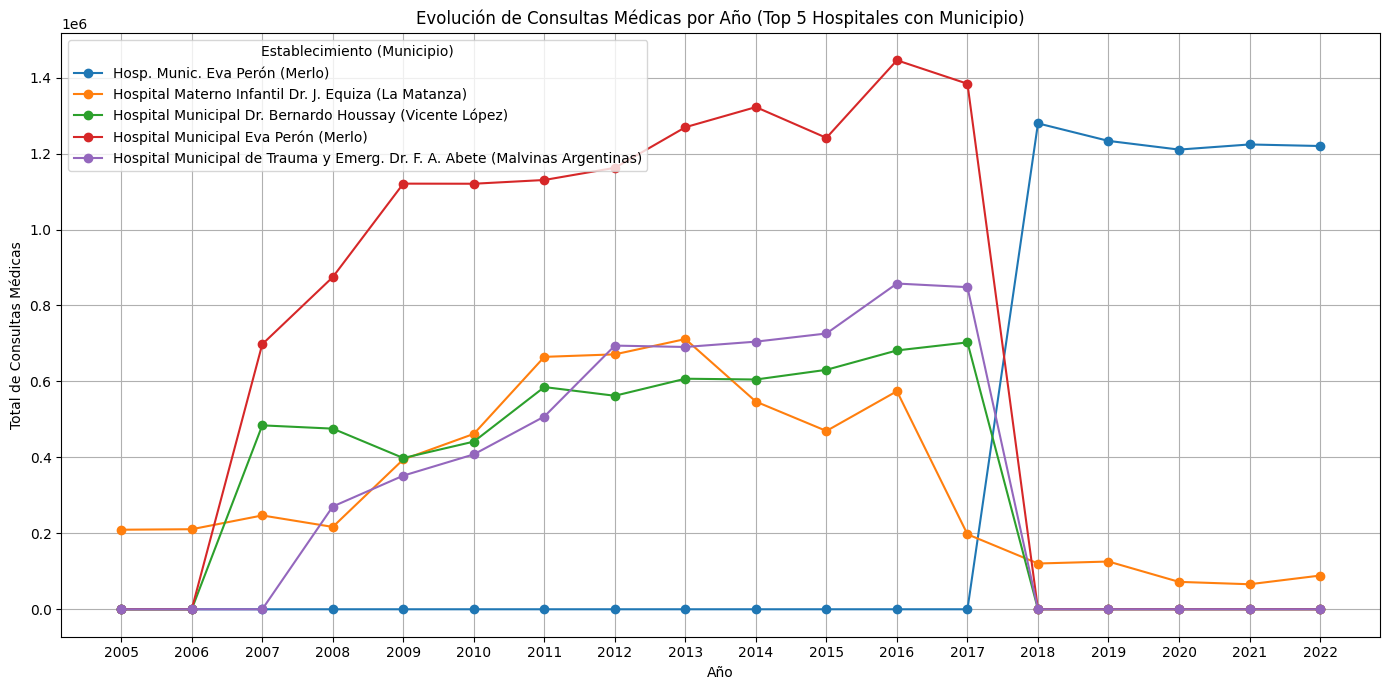

In [23]:
# Filtrar solo hospitales
df_hospitales = df_final[df_final['tipo_establecimiento'] == 1].copy()

# **NUEVO PASO: Concatenar municipio_nombre al establecimiento_nombre**
# Asegurarse de que ambas columnas sean de tipo string para la concatenación
df_hospitales['establecimiento_nombre'] = df_hospitales['establecimiento_nombre'].astype(str) + ' (' + df_hospitales['municipio_nombre'].astype(str) + ')'


# Agrupar por establecimiento_nombre (ahora incluye el municipio) y anio y sumar las consultas medicas
df_grouped = df_hospitales.groupby(['establecimiento_nombre', 'anio'])['consultas_medicas'].sum().reset_index()

# Tomar los 5 hospitales con mayor número total de consultas medicas a lo largo de los años
top_5_establecimientos = df_grouped.groupby('establecimiento_nombre')['consultas_medicas'].sum().nlargest(5).index.tolist()

# Filtrar el dataframe agrupado para incluir solo los top 5 hospitales
df_top_5 = df_grouped[df_grouped['establecimiento_nombre'].isin(top_5_establecimientos)]

# Pivotear para facilitar la graficación (años como columnas)
df_pivot = df_top_5.pivot(index='anio', columns='establecimiento_nombre', values='consultas_medicas').fillna(0)

# Graficar
plt.figure(figsize=(14, 7))
for col in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[col], marker='o', linestyle='-', label=col)

# Añadir título y etiquetas
plt.title('Evolución de Consultas Médicas por Año (Top 5 Hospitales con Municipio)')
plt.xlabel('Año')
plt.ylabel('Total de Consultas Médicas')
plt.legend(title='Establecimiento (Municipio)') # Actualizar el título de la leyenda
plt.grid(True)
plt.xticks(df_pivot.index) # Asegurar que se muestren todos los años presentes
plt.tight_layout()
plt.show()

#### 📈 Segundo gráfico bien agrupado (salvamos la diferencia de nombres y mismo id por lo tanto muestra los datos reales)

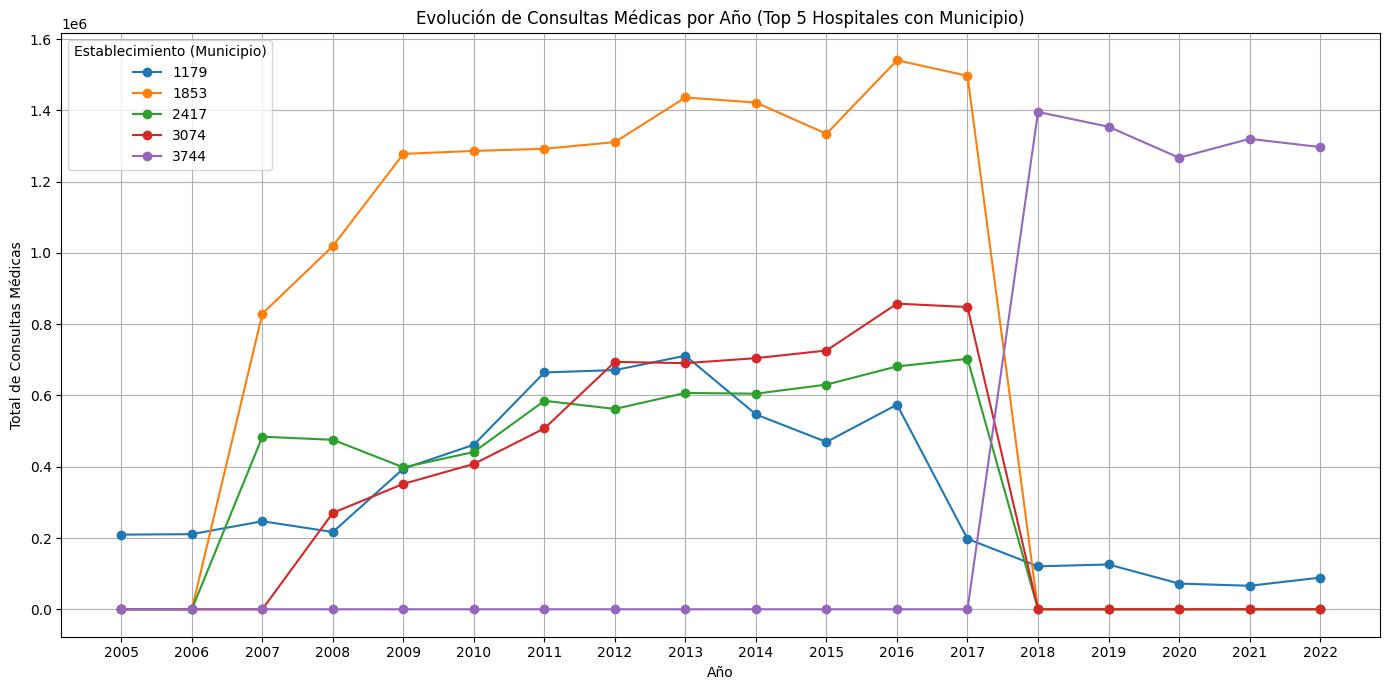

In [24]:
# Filtrar solo hospitales
df_hospitales = df_final[df_final['tipo_establecimiento'] == 1].copy()

# **NUEVO PASO: Concatenar municipio_nombre al establecimiento_nombre**
# Asegurarse de que ambas columnas sean de tipo string para la concatenación
df_hospitales['establecimiento_nombre'] = df_hospitales['establecimiento_nombre'].astype(str) + ' (' + df_hospitales['municipio_nombre'].astype(str) + ')'


# Agrupar por establecimiento_nombre (ahora incluye el municipio) y anio y sumar las consultas medicas
df_grouped = df_hospitales.groupby(['establecimiento_id', 'anio'])['consultas_medicas'].sum().reset_index()

# Tomar los 5 hospitales con mayor número total de consultas medicas a lo largo de los años
top_5_establecimientos = df_grouped.groupby('establecimiento_id')['consultas_medicas'].sum().nlargest(5).index.tolist()

# Filtrar el dataframe agrupado para incluir solo los top 5 hospitales
df_top_5 = df_grouped[df_grouped['establecimiento_id'].isin(top_5_establecimientos)]

# Pivotear para facilitar la graficación (años como columnas)
df_pivot = df_top_5.pivot(index='anio', columns='establecimiento_id', values='consultas_medicas').fillna(0)

# Graficar
plt.figure(figsize=(14, 7))
for col in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[col], marker='o', linestyle='-', label=col)

# Añadir título y etiquetas
plt.title('Evolución de Consultas Médicas por Año (Top 5 Hospitales con Municipio)')
plt.xlabel('Año')
plt.ylabel('Total de Consultas Médicas')
plt.legend(title='Establecimiento (Municipio)') # Actualizar el título de la leyenda
plt.grid(True)
plt.xticks(df_pivot.index) # Asegurar que se muestren todos los años presentes
plt.tight_layout()
plt.show()

En base a este caso decidimos actualizar los nombres diferentes para un mismo id en el dataframe:

In [25]:
# 1. Crear un mapeo de establecimiento_id a un nombre representativo
# Agrupar por establecimiento_id y contar la frecuencia de cada establecimiento_nombre

nombre_counts = df_final.groupby('establecimiento_id')['establecimiento_nombre'].value_counts().reset_index(name='count')

# Para cada establecimiento_id, tomar el establecimiento_nombre con la mayor frecuencia
# Esto se hace ordenando por cuenta descendente y tomando el primero de cada grupo de establecimiento_id
idx = nombre_counts.groupby('establecimiento_id')['count'].idxmax()
mapeo_nombre_establecimiento = nombre_counts.loc[idx].set_index('establecimiento_id')['establecimiento_nombre'].to_dict()

print("Ejemplo del mapeo de establecimiento_id a nombre unificado (primeros 10):")
print(list(mapeo_nombre_establecimiento.items())[:10])

# 2. Aplicar el mapeo al DataFrame original
# Usamos .map() en la columna establecimiento_id para obtener el nombre unificado
# Esto creará una nueva columna temporal o reemplazará la existente
df_final['establecimiento_nombre_unificado'] = df_final['establecimiento_id'].map(mapeo_nombre_establecimiento)

# Reemplazar la columna original establecimiento_nombre con la unificada
# Si quieres mantener la columna original con los nombres tal cual vienen, puedes omitir esta línea
df_final['establecimiento_nombre'] = df_final['establecimiento_nombre_unificado']

# Eliminar la columna temporal
df_final = df_final.drop('establecimiento_nombre_unificado', axis=1)

# 3. Verificación
print("\nVerificando si quedan múltiples establecimiento_nombre por establecimiento_id:")
nombre_verificacion = df_final.groupby('establecimiento_id')['establecimiento_nombre'].nunique()
establecimientos_con_multiples_nombres = nombre_verificacion[nombre_verificacion > 1]

if not establecimientos_con_multiples_nombres.empty:
    print("\nLos siguientes establecimiento_id aún tienen múltiples establecimiento_nombre:")
    print(establecimientos_con_multiples_nombres)

else:
    print("\nTodos los establecimiento_id ahora tienen un único establecimiento_nombre asociado (según el mapeo creado).")

print("\nPrimeras filas con establecimiento_nombre unificado:")
print(df_final[['establecimiento_id', 'establecimiento_nombre']].head())



Ejemplo del mapeo de establecimiento_id a nombre unificado (primeros 10):
[(1, 'Hospital Local General José de San Martín'), (2, 'Hospital Dr. Noe Yarcho'), (3, 'Hogar de Ancianos General N. Levalle'), (4, 'Hospital Demetrio Carmelo Loyarte'), (5, 'Unidad Sanitaria San Miguel Arcangel'), (6, 'Unidad Sanitaria Colonia Lapin'), (7, 'Unidad Sanitaria Dr. J.C. Senepart'), (8, 'Unidad Sanitaria Murature'), (9, 'Unidad Sanitaria Barrio Arturo Illia'), (10, 'Unidad Sanitaria Villa Goldberg')]

Verificando si quedan múltiples establecimiento_nombre por establecimiento_id:

Todos los establecimiento_id ahora tienen un único establecimiento_nombre asociado (según el mapeo creado).

Primeras filas con establecimiento_nombre unificado:
   establecimiento_id                     establecimiento_nombre
0                   1  Hospital Local General José de San Martín
1                   2                    Hospital Dr. Noe Yarcho
2                   3       Hogar de Ancianos General N. Levalle
3     

Ejecutamos el PRIMER GRAFICO ahora bien AGRUPADO por id y vemos que coincide con el segundo gráfico donde tuvimos que agrupar por nombre del establecimiento, Se normalizaron los datos.

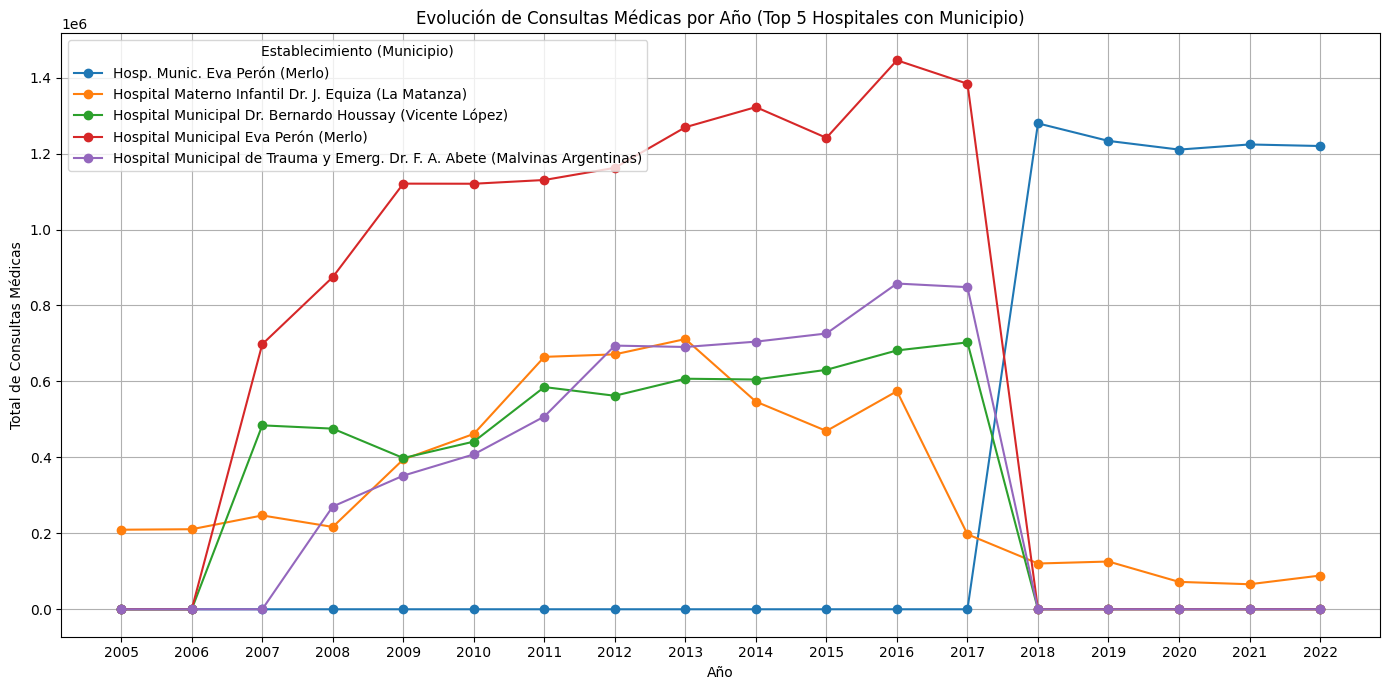

In [26]:
# Filtrar solo hospitales
df_hospitales = df_final[df_final['tipo_establecimiento'] == 1].copy()

# **NUEVO PASO: Concatenar municipio_nombre al establecimiento_nombre**
# Asegurarse de que ambas columnas sean de tipo string para la concatenación
df_hospitales['establecimiento_nombre'] = df_hospitales['establecimiento_nombre'].astype(str) + ' (' + df_hospitales['municipio_nombre'].astype(str) + ')'


# Agrupar por establecimiento_nombre (ahora incluye el municipio) y anio y sumar las consultas medicas
df_grouped = df_hospitales.groupby(['establecimiento_nombre', 'anio'])['consultas_medicas'].sum().reset_index()

# Tomar los 5 hospitales con mayor número total de consultas medicas a lo largo de los años
top_5_establecimientos = df_grouped.groupby('establecimiento_nombre')['consultas_medicas'].sum().nlargest(5).index.tolist()

# Filtrar el dataframe agrupado para incluir solo los top 5 hospitales
df_top_5 = df_grouped[df_grouped['establecimiento_nombre'].isin(top_5_establecimientos)]

# Pivotear para facilitar la graficación (años como columnas)
df_pivot = df_top_5.pivot(index='anio', columns='establecimiento_nombre', values='consultas_medicas').fillna(0)

# Graficar
plt.figure(figsize=(14, 7))
for col in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[col], marker='o', linestyle='-', label=col)

# Añadir título y etiquetas
plt.title('Evolución de Consultas Médicas por Año (Top 5 Hospitales con Municipio)')
plt.xlabel('Año')
plt.ylabel('Total de Consultas Médicas')
plt.legend(title='Establecimiento (Municipio)') # Actualizar el título de la leyenda
plt.grid(True)
plt.xticks(df_pivot.index) # Asegurar que se muestren todos los años presentes
plt.tight_layout()
plt.show()

#### 🧪 Evolución de consultas médicas por establecimiento y año — no hospitales

Analizamos los primeros 5 establecimientos. Del análisis surge que:

* Los hogares de Ancianos no tienen consultas médicas.
* Los establecimientos que brindan servicio de antropozoonosis (enfermedades que se transmiten de humanos a animales) tuvieron pocas consultas médicas y se mantuvo estable no tuvo valores fuera de la curva.
* Los centros antirrábicos humanos (prevenir y tratar la rabia en humanos) tuvieron un patrón de crecimiento a partir del año 2009 y se mantuvo ligeramente constante a lo largo de los años hasta el 2022.
* La unidad de salud ambiental tuvo un crecimiento exponencial desde su fecha de inauguración hasta el 2022.

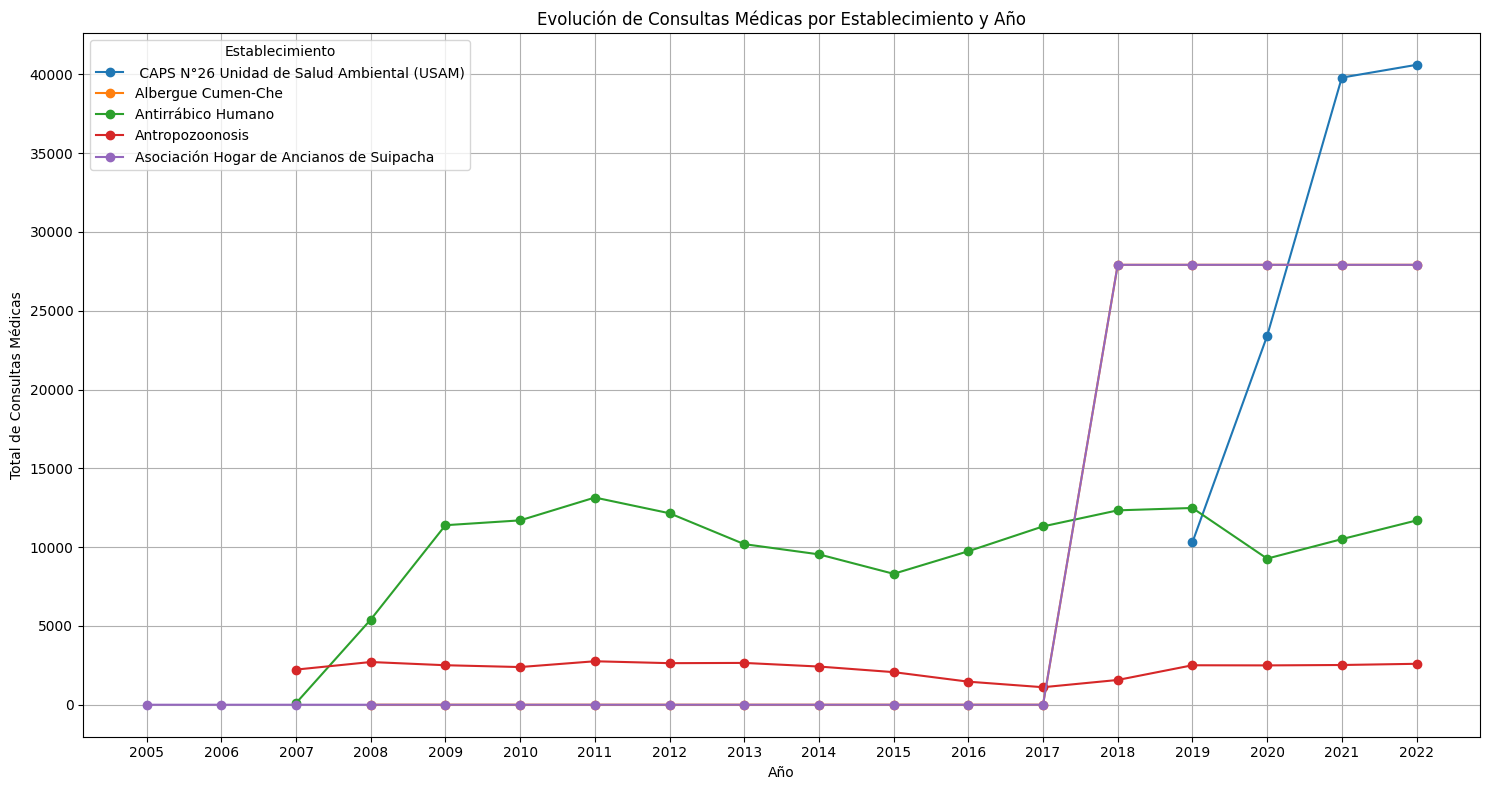

In [27]:
# Agrupar por establecimiento_nombre y anio y sumar las consultas medicas
df_agrupado_consultas = df.groupby(['establecimiento_nombre', 'anio'])['consultas_medicas'].sum().reset_index()

# Seleccionar algunos establecimientos para visualizar (puedes ajustar esta lista)
establecimientos_a_graficar = df_agrupado_consultas['establecimiento_nombre'].unique()[:5] # Tomar los primeros 5

# Crear un gráfico de líneas para mostrar la evolución de las consultas médicas por año para cada establecimiento
plt.figure(figsize=(15, 8)) # Ajustar el tamaño del gráfico

for establecimiento in establecimientos_a_graficar:
    df_establecimiento = df_agrupado_consultas[df_agrupado_consultas['establecimiento_nombre'] == establecimiento]
    plt.plot(df_establecimiento['anio'], df_establecimiento['consultas_medicas'], marker='o', label=establecimiento)

# Añadir título y etiquetas
plt.title('Evolución de Consultas Médicas por Establecimiento y Año')
plt.xlabel('Año')
plt.ylabel('Total de Consultas Médicas')
plt.grid(True)
plt.legend(title='Establecimiento')
plt.xticks(df_agrupado_consultas['anio'].unique()) # Asegura que se muestren todos los años en el eje x
plt.tight_layout()
plt.show()

### 🧮 Estadisticas descriptivas

In [28]:
# ESTADISTICAS DESCRIPTIVAS

# AÑO DE INGRESO DE LA CONSULTA MEDICA
df['anio'].describe()

count    38993.000000
mean      2013.767163
std          5.161545
min       2005.000000
25%       2009.000000
50%       2014.000000
75%       2018.000000
max       2022.000000
Name: anio, dtype: float64

Text(0, 0.5, 'Frecuencia')

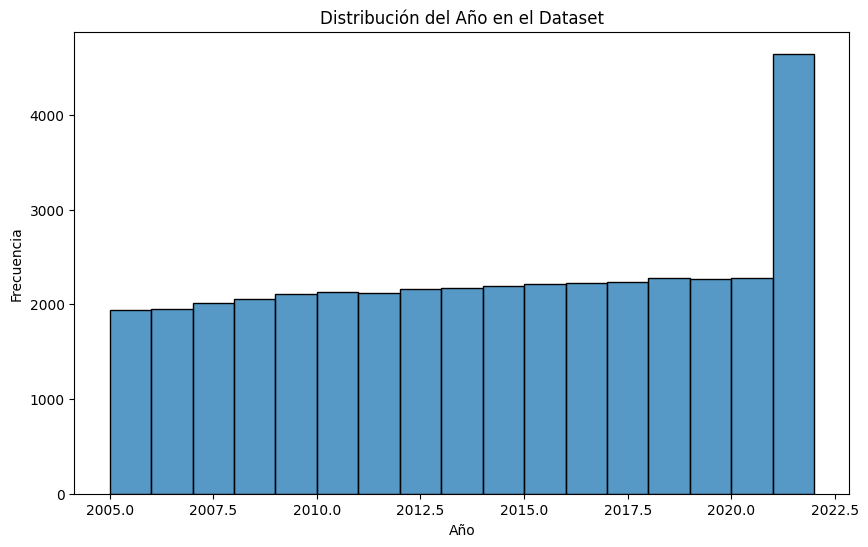

In [29]:
# Crear un histograma de la columna 'anio'
plt.figure(figsize=(10, 6)) # Ajustar el tamaño del gráfico
sns.histplot(data=df, x='anio', bins=sorted(df['anio'].unique()), kde=False) # bins para cada año único, kde=False desactiva la curva de densidad

# Añadir título y etiquetas
plt.title('Distribución del Año en el Dataset')
plt.xlabel('Año')
plt.ylabel('Frecuencia')


#### 📊 Gráfico de los establecimientos con mayor cantidad de consultas

Los cuatro gráficos visualizan los establecimientos con mayor volumen de actividad para diferentes tipos de consultas médicas registradas en el conjunto de datos a lo largo de los años 2005-2022. Cada gráfico de barras muestra la suma total del tipo de consulta respectivo para los 10 establecimientos principales en esa categoría específica.

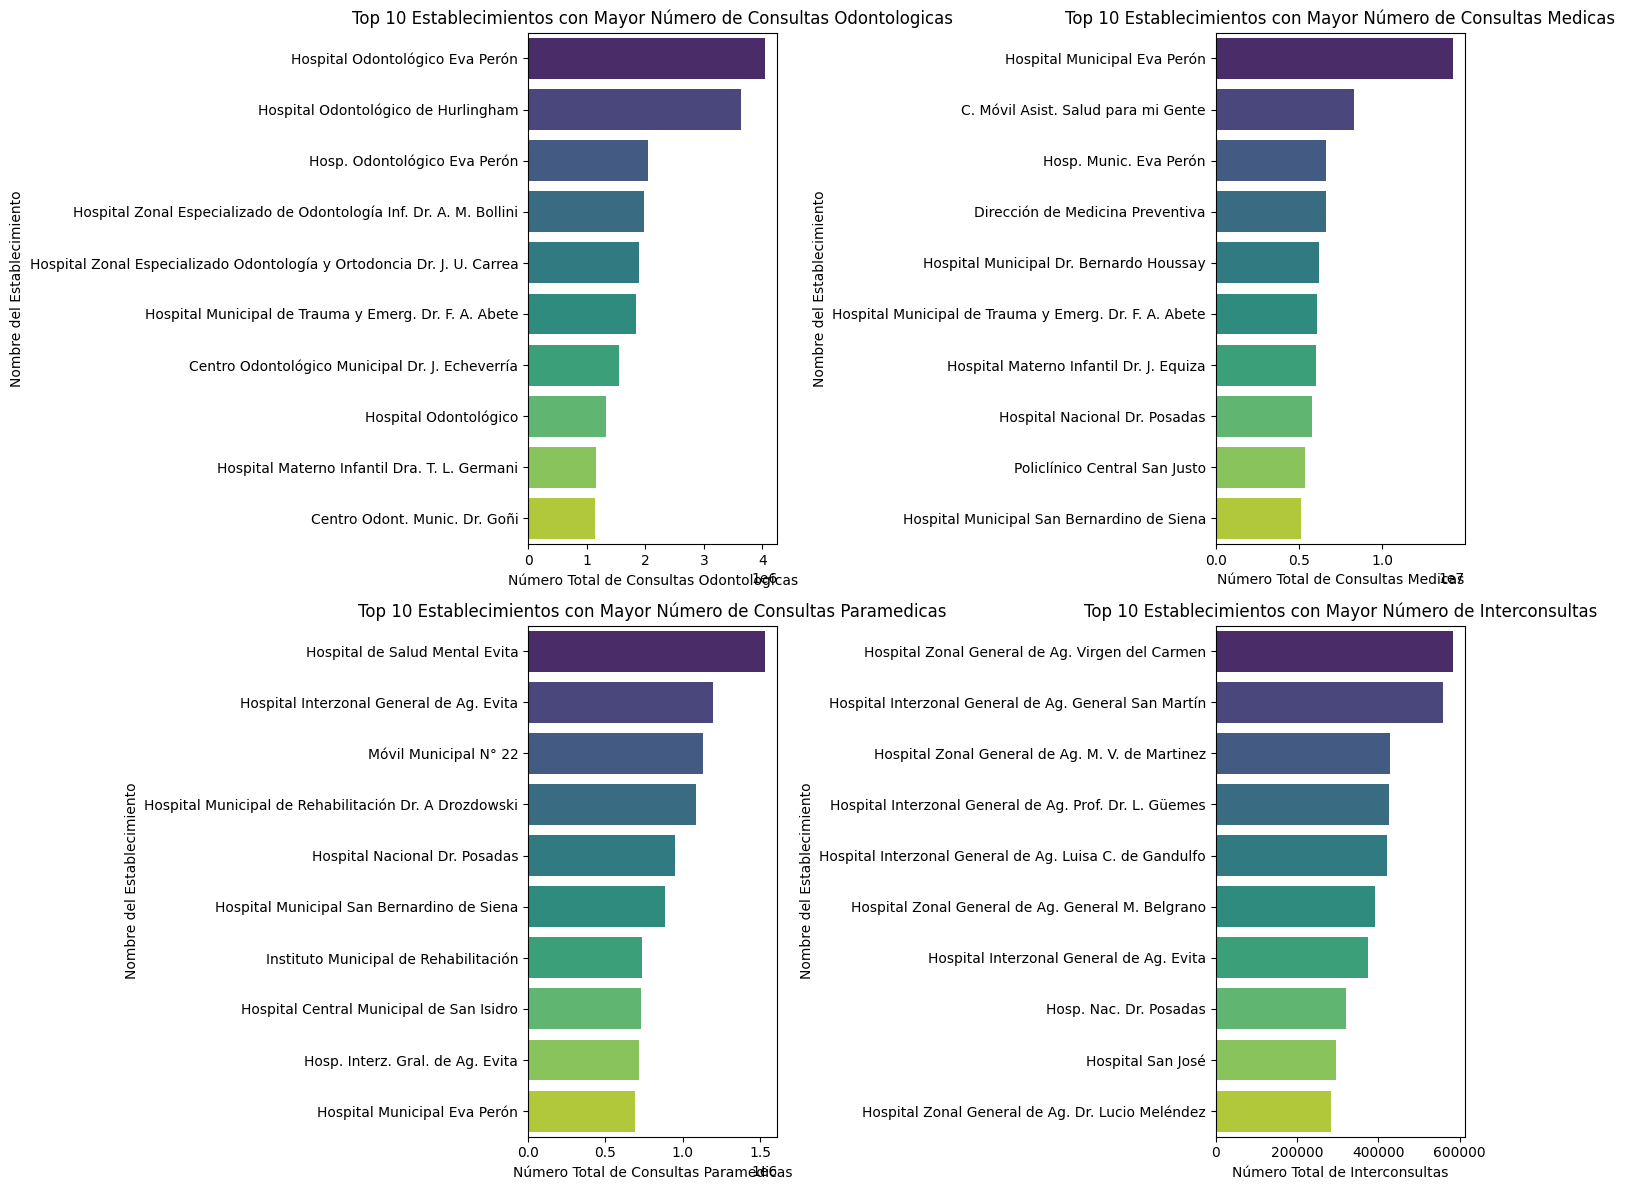

In [30]:
# Lista de columnas de interés para los gráficos
consulta_cols = ['consultas_odontologicas', 'consultas_medicas', 'consultas_paramedicas', 'interconsultas']

# Número de top establecimientos a mostrar en cada gráfico
top_n = 10

# Crear una figura y un conjunto de subplots (2 filas, 2 columnas)
fig, axes = plt.subplots(2, 2, figsize=(15, 12)) # Ajustar el tamaño general de la figura

# Aplanar el array de ejes para poder iterar fácilmente
axes = axes.flatten()

# Iterar sobre cada columna y crear un gráfico
for i, col in enumerate(consulta_cols):
    # 1. Agrupar por establecimiento_nombre y sumar la columna actual
    # Asegurarse de que la columna exista en el DataFrame
    if col in df.columns:
        total_por_establecimiento = df.groupby('establecimiento_nombre')[col].sum().reset_index()

        # 2. Ordenar por el total de la columna actual de forma descendente
        total_por_establecimiento_orden = total_por_establecimiento.sort_values(by=col, ascending=False)

        # 3. Seleccionar los top N establecimientos para visualizar
        top_establecimientos = total_por_establecimiento_orden.head(top_n)

        # 4. Crear un gráfico de barras en el subplot correspondiente
        sns.barplot(x=col, y='establecimiento_nombre', data=top_establecimientos, palette='viridis', ax=axes[i], hue='establecimiento_nombre')

        # Añadir título y etiquetas al subplot
        axes[i].set_title(f'Top {top_n} Establecimientos con Mayor Número de {col.replace("_", " ").title()}') # Título descriptivo
        axes[i].set_xlabel(f'Número Total de {col.replace("_", " ").title()}')
        axes[i].set_ylabel('Nombre del Establecimiento')

        # Mejorar el layout del subplot si es necesario (aunque tight_layout al final ayuda)
        # axes[i].tight_layout() # Esto se hace mejor una vez al final para toda la figura
    else:
        print(f"Advertencia: La columna '{col}' no se encontró en el DataFrame.")
        # Opcional: Ocultar el subplot si la columna no existe
        fig.delaxes(axes[i])


# Ajustar el layout general de la figura para evitar solapamientos
plt.tight_layout()

# Mostrar la figura con todos los subplots
plt.show()


## ⚙️ Escalado

### ¿Por qué escalamos los datos?

Tomemos un ejemplo claro con dos features:  
- **`consultas_medicas`** (valores desde 0 hasta miles)  
- **`porcentaje_ocupacion`** (valores entre 0 y 100)  

Si alimentamos estos datos directamente a un algoritmo como **K-Nearest Neighbors (KNN)** o **Support Vector Machines (SVM)**, que calculan distancias entre puntos, la feature con valores más grandes (**consultas_medicas**) dominará el cálculo de la distancia, haciendo que la feature con valores más pequeños (**porcentaje_ocupacion**) sea prácticamente ignorada, incluso si es muy relevante para la predicción.

---

#### ¿Para qué sirve el escalado?

El escalado nos ayuda a **equilibrar la influencia de todas las features**, asegurando que ninguna domine artificialmente el proceso de aprendizaje debido a su magnitud.

---

#### Escalado con RobustScaler

Vamos a utilizar el **RobustScaler** de la librería `sklearn.preprocessing`.

- **¿Por qué RobustScaler?**  
  Este escalador es particularmente útil cuando tus datos contienen **outliers** (valores atípicos).  
  A diferencia de `StandardScaler` (que usa la media y desviación estándar, sensibles a outliers), RobustScaler utiliza:  
  - La **mediana** (valor central que no se afecta por valores extremos)  
  - El **rango intercuartílico (IQR)**, que es la diferencia entre el 75º y 25º percentil, representando la dispersión de la mitad central de los datos, ignorando extremos.

---

#### Fórmula de escalado RobustScaler

\[
x\_scaled[j] = \frac{x[j] - \text{mediana}[j]}{\text{IQR}[j]}
\]

donde:  
- \(x[j]\) es el valor original de la feature \(j\)  
- \(\text{mediana}[j]\) es la mediana de la feature \(j\)  
- \(\text{IQR}[j]\) es el rango intercuartílico de la feature \(j\)

Así, el RobustScaler reduce la influencia de valores atípicos y escala cada feature para que contribuyan de forma equilibrada al aprendizaje.


In [31]:
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer


In [35]:
df.columns

Index(['anio', 'region_sanitaria', 'municipio_id', 'municipio_nombre',
       'establecimiento_nombre', 'dependencia', 'consultas_odontologicas',
       'consultas_medicas', 'consultas_paramedicas', 'interconsultas',
       'egresos', 'dias_camas_disponible', 'promedio_camas_disponibles',
       'pacientes_dias', 'porcentaje_ocupacion', 'dias_estadia',
       'promedio_dias_estadia', 'defunciones', 'giro_de_camas',
       'tasa_mortalidad_hospitalaria', 'dependencia_id', 'establecimiento_id'],
      dtype='object')

In [36]:
# Definimos las features numéricas y categóricas:
numeric_features = [
    'consultas_medicas', 'consultas_paramedicas',
    'interconsultas', 'egresos', 'dias_camas_disponible', 'promedio_camas_disponibles',
    'pacientes_dias', 'porcentaje_ocupacion', 'dias_estadia',
    'defunciones', 'giro_de_camas', 'tasa_mortalidad_hospitalaria'
]
categorical_features = ['dependencia_id', 'region_sanitaria']

# Definimos la variable objetivo (target) validamos que exista en df_final
target = 'promedio_dias_estadia'

# Seleccionamos features y target, manejando NaNs antes de dividir
X = df_final[numeric_features + categorical_features].copy()
y = df_final[target].copy()

#DIVIDIMOS LOS DATOS
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nDatos divididos en Train y Test.")
print(f"Forma de X_train: {X_train.shape}")

# --- Configuramos el escalado usando ColumnTransformer ---
print("\n--- Realizando Escalado ---")

# Definimos las columnas numéricas a ser escaladas
cols_to_scale = numeric_features # Usamos la lista definida arriba

# utilizamos RobustScaler porque es menos sensible a outliers
scaler = RobustScaler()

# ColumnTransformer lo usamos para aplicar el escalador solo a las columnas numéricas
# el parámetro 'passthrough' en remainder permite mantener las columnas no listadas sin modificar
preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, cols_to_scale)
    ],
    remainder='passthrough'
)

# --- Aplicamos el escalado ---

# 1. Ajustamos el preprocesador (scaler) en el conjunto de ENTRENAMIENTO
#    El preprocesador calcula los parámetros de escalado (media/std o mediana/IQR)
#    basándose ÚNICAMENTE en X_train.
print("Ajustando el escalador en X_train...")
preprocessor.fit(X_train)

# 2. Transformamos el conjunto de ENTRENAMIENTO
#    Aplica el escalado aprendido a X_train.
print("Transformando X_train...")
X_train_scaled = preprocessor.transform(X_train)

# 3. Transformamos el conjunto de PRUEBA
#    Aplicamos el mismo escalado aprendido de X_train a X_test.
print("Transformando X_test...")
X_test_scaled = preprocessor.transform(X_test)

print("Escalado completado.")
print(f"Forma de X_train_scaled: {X_train_scaled.shape}")
print(f"Forma de X_test_scaled: {X_test_scaled.shape}")

# X_train_scaled y X_test_scaled son ahora arrays de NumPy.
# Las primeras columnas corresponden a las features numéricas escaladas y
# las columnas restantes son las otras columnas originales.

try:
    feature_names_out = preprocessor.get_feature_names_out()
    print("\nNombres de las features después del escalado:")
    print(feature_names_out)

    # Convertimos el DataFrame para inspeccionarlo
    X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names_out, index=X_train.index)
    X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=feature_names_out, index=X_test.index)

    print("\nEstadísticas descriptivas de las features numéricas escaladas (X_train_scaled):")
    # Seleccionamos solo las columnas que fueron escaladas (las primeras en feature_names_out)
    scaled_cols_df = X_train_scaled_df.iloc[:, :len(cols_to_scale)]
    print(scaled_cols_df.describe())

    # Con RobustScaler, la mediana debería estar cerca de 0 y el IQR cerca de 1.

except AttributeError:
    print("\nTu versión de scikit-learn no soporta get_feature_names_out. No se puede mostrar fácilmente el resultado como DataFrame.")
    print("X_train_scaled y X_test_scaled son arrays de NumPy.")



Datos divididos en Train y Test.
Forma de X_train: (31194, 14)

--- Realizando Escalado ---
Ajustando el escalador en X_train...
Transformando X_train...
Transformando X_test...
Escalado completado.
Forma de X_train_scaled: (31194, 14)
Forma de X_test_scaled: (7799, 14)

Nombres de las features después del escalado:
['num__consultas_medicas' 'num__consultas_paramedicas'
 'num__interconsultas' 'num__egresos' 'num__dias_camas_disponible'
 'num__promedio_camas_disponibles' 'num__pacientes_dias'
 'num__porcentaje_ocupacion' 'num__dias_estadia' 'num__defunciones'
 'num__giro_de_camas' 'num__tasa_mortalidad_hospitalaria'
 'remainder__dependencia_id' 'remainder__region_sanitaria']

Estadísticas descriptivas de las features numéricas escaladas (X_train_scaled):
        num__consultas_medicas  num__consultas_paramedicas  \
count             31194.000000                31194.000000   
unique            19568.000000                 8901.000000   
top                  -0.348664                   

### 📐 Histogramas

Graficamos algunos aspectos de los datos después del preprocesamiento y escalado. Dado que el escalado ya se ha aplicado a las features numéricas y las categóricas se han mantenido, podemos visualizar las distribuciones de las features numéricas escaladas o la relación entre el target (promedio_dias_estadia) y una de las features numéricas.

#### Histograma para visualizar los valores escalados de consultas medicas

El gráfico de distribución de num__consultas_medicas (Escalado) nos muestra cómo se agrupan los datos de consultas_medicas una vez que han sido centrados por su mediana y escalados por su rango intercuartílico. Nos permite confirmar visualmente que el escalado ha sido aplicado (viendo el pico cerca de 0) y observar la forma de la distribución transformada, incluyendo la presencia de outliers que se manifiestan como valores alejados de 0. Es una forma de inspeccionar el resultado del preprocesamiento en una feature específica.

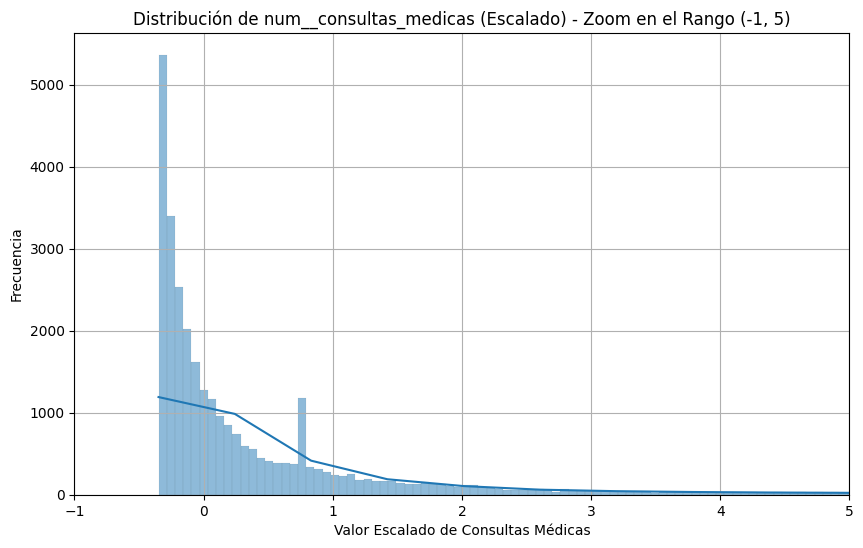

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecciona la columna numérica escalada específica para visualizar
scaled_feature_to_plot = 'num__consultas_medicas'

# Asegúrate de que la feature escalada exista en el DataFrame escalado
if scaled_feature_to_plot not in X_train_scaled_df.columns:
     print(f"La columna '{scaled_feature_to_plot}' no se encontró en el DataFrame escalado. Verifica los nombres de feature_names_out.")
else:
    plt.figure(figsize=(10, 6)) # Puedes ajustar el tamaño de la figura si quieres que el gráfico sea más grande en general

    # Crea el histograma para la feature escalada
    sns.histplot(X_train_scaled_df[scaled_feature_to_plot], kde=True)

    # --- Ajustar los límites del Eje X para acercar el zoom ---

    x_min = -1  # Valor mínimo para el eje X
    x_max = 5  # Valor máximo para el eje X
    plt.xlim(x_min, x_max) # Establece los límites del eje X

    # Añade título y etiquetas
    plt.title(f'Distribución de {scaled_feature_to_plot} (Escalado) - Zoom en el Rango ({x_min}, {x_max})') # Actualiza el título para indicar el zoom
    plt.xlabel('Valor Escalado de Consultas Médicas')
    plt.ylabel('Frecuencia')

    # Muestra el gráfico
    plt.grid(True) # Opcional: añade una cuadrícula
    plt.show()

#### Histograma para visualizar los valores escalados de camas disponibles

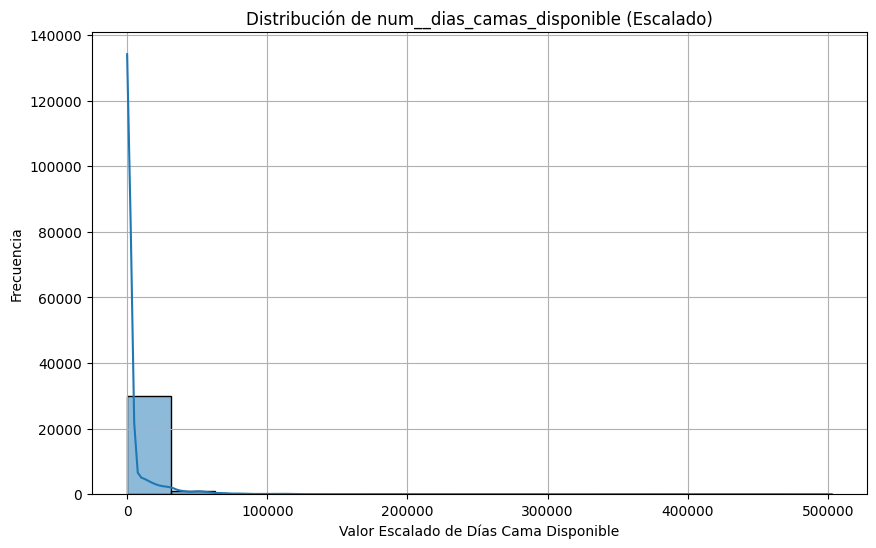

In [38]:
# Selecciona la columna numérica escalada específica para visualizar
scaled_feature_to_plot = 'num__dias_camas_disponible'

# Asegúrate de que la feature escalada exista en el DataFrame escalado
if scaled_feature_to_plot not in X_train_scaled_df.columns:
     print(f"La columna '{scaled_feature_to_plot}' no se encontró en el DataFrame escalado. Verifica los nombres de feature_names_out.")
else:
    plt.figure(figsize=(10, 6)) # Ajusta el tamaño del gráfico si es necesario

    # Crea el histograma para la feature escalada
    sns.histplot(X_train_scaled_df[scaled_feature_to_plot], kde=True) # kde=True añade la curva de densidad

    # Añade título y etiquetas
    plt.title(f'Distribución de {scaled_feature_to_plot} (Escalado)')
    plt.xlabel('Valor Escalado de Días Cama Disponible') # Etiqueta del eje X
    plt.ylabel('Frecuencia') # Etiqueta del eje Y

    # Muestra el gráfico
    plt.grid(True) # Opcional: añade una cuadrícula
    plt.show()

## 📈 Modelo de Regresión Lineal Simple

#### 📉 Gráfico de regresión lineal simple (train y test)

Este gráfico muestra el proceso de aprendizaje y la evaluación de nuestro modelo de regresión lineal simple, visualizando la relación entre la variable `pacientes_dias` y la variable `promedio_dias_estadia`.

- 🟢 **Puntos verdes (datos de entrenamiento):**  
  Cada punto verde representa una observación del conjunto de datos de entrenamiento. Estos datos fueron usados para que el modelo aprenda la relación entre `pacientes_dias` y `promedio_dias_estadia`. La línea de regresión se ajusta para minimizar el error en estos puntos.

- 🔵 **Puntos azules (datos de prueba):**  
  Cada punto azul corresponde a una observación del conjunto de datos de prueba. Estos datos no se usaron durante el entrenamiento y sirven para evaluar qué tan bien el modelo generaliza a datos nuevos.

- 🔴 **Línea roja (predicción del modelo):**  
  Esta línea recta representa la función ajustada por el modelo, calculada únicamente a partir de los datos de entrenamiento (puntos verdes). Muestra la relación lineal que el modelo encontró y predice el valor de `promedio_dias_estadia` para cualquier valor de `pacientes_dias`.

---

#### 🔍 Qué podemos observar en el gráfico

- ✔️ **Ajuste al entrenamiento:** La línea roja debería estar cerca de los puntos verdes si el modelo se entrenó correctamente.

- ✔️ **Generalización:** Comparando la línea roja con los puntos azules, podemos evaluar la capacidad del modelo para predecir datos no vistos.  
  - Si la línea se ajusta bien a los puntos azules, el modelo generaliza bien.  
  - Si hay una gran diferencia entre el ajuste a puntos verdes y azules, podría indicar sobreajuste (overfitting).

---

En resumen, este gráfico nos ofrece una visión completa del rendimiento del modelo, mostrando tanto lo que aprendió como su capacidad para aplicar ese aprendizaje a datos nuevos.


In [45]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def mejores_pares_dos_vars(df, posibles_dependientes, posibles_independientes):
    resultados = []
    for dep in posibles_dependientes:
        for indep in posibles_independientes:
            if indep == dep:
                continue
            
            X = df[[indep]]
            y = df[dep]
            
            # Quitar filas con nulos en estas dos columnas
            mask = X[indep].notnull() & y.notnull()
            X_clean = X[mask]
            y_clean = y[mask]
            
            if X_clean.empty:
                continue
            
            model = LinearRegression()
            model.fit(X_clean, y_clean)
            y_pred = model.predict(X_clean)
            r2 = r2_score(y_clean, y_pred)
            
            resultados.append((dep, indep, r2))
    
    # Ordenar por r2 descendente
    resultados.sort(key=lambda x: x[2], reverse=True)
    return resultados

# Listas de variables numéricas posibles
variables_num = [
    'anio', 'consultas_odontologicas', 'consultas_medicas', 'consultas_paramedicas',
    'interconsultas', 'egresos', 'dias_camas_disponible', 'promedio_camas_disponibles',
    'pacientes_dias', 'porcentaje_ocupacion', 'dias_estadia', 'promedio_dias_estadia',
    'defunciones', 'giro_de_camas', 'tasa_mortalidad_hospitalaria'
]

# Probar todas las variables numéricas como dependientes e independientes
resultados_todos = mejores_pares_dos_vars(df_final, variables_num, variables_num)

# Mostrar los 10 mejores pares con su R2
for dep, indep, r2 in resultados_todos[:10]:
    print(f'Dependiente: {dep} | Independiente: {indep} | R²: {r2:.4f}')


Dependiente: dias_camas_disponible | Independiente: promedio_camas_disponibles | R²: 0.9931
Dependiente: promedio_camas_disponibles | Independiente: dias_camas_disponible | R²: 0.9931
Dependiente: dias_camas_disponible | Independiente: pacientes_dias | R²: 0.9696
Dependiente: pacientes_dias | Independiente: dias_camas_disponible | R²: 0.9696
Dependiente: promedio_camas_disponibles | Independiente: pacientes_dias | R²: 0.9637
Dependiente: pacientes_dias | Independiente: promedio_camas_disponibles | R²: 0.9637
Dependiente: pacientes_dias | Independiente: dias_estadia | R²: 0.8908
Dependiente: dias_estadia | Independiente: pacientes_dias | R²: 0.8908
Dependiente: dias_camas_disponible | Independiente: dias_estadia | R²: 0.8584
Dependiente: dias_estadia | Independiente: dias_camas_disponible | R²: 0.8584


Métricas de evaluación para la Regresión Lineal Simple (dias_camas_disponible vs pacientes_dias):
Error Absoluto Medio (MAE): 1016.83
Error Cuadrático Medio (MSE): 7401199.12
Coeficiente de Determinación (R²): 0.96


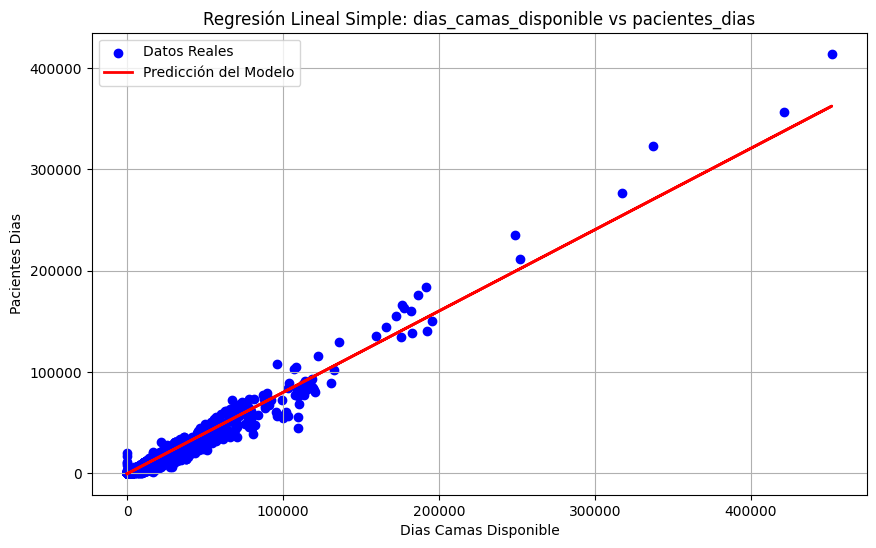

In [49]:
#Dependiente: pacientes_dias | Independiente: dias_camas_disponible | R²: 0.9696

variable_independiente = 'dias_camas_disponible' # Variable predictora (X)
variable_dependiente = 'pacientes_dias' # Variable a predecir (y)

# Asegurarse de que las columnas seleccionadas existan y no tengan valores infinitos
if variable_independiente not in df_final.columns or variable_dependiente not in df_final.columns:
    print(f"Error: Una o ambas columnas '{variable_independiente}' o '{variable_dependiente}' no existen en el DataFrame.")
else:
    # Filtrar filas con valores infinitos en las columnas seleccionadas si es necesario
    df_regresion = df_final.replace([np.inf, -np.inf], np.nan).dropna(subset=[variable_independiente, variable_dependiente]).copy()

    # Asegurarse de que haya suficientes datos para la regresión
    if len(df_regresion) == 0:
        print(f"Error: No hay datos válidos para las columnas '{variable_independiente}' y '{variable_dependiente}' después de limpiar infinitos y NaN.")
    else:
        # 2. Preparar los datos para el modelo
        # Es necesario que la variable independiente (X) sea un array 2D
        X = df_regresion[[variable_independiente]]
        y = df_regresion[variable_dependiente]

        # 3. Dividir los datos en conjuntos de entrenamiento y prueba
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # 20% para prueba

        # 4. Crear el modelo de regresión lineal
        modelo = LinearRegression()

        # 5. Entrenar el modelo
        modelo.fit(X_train, y_train)

        # 6. Hacer predicciones en el conjunto de prueba
        y_pred = modelo.predict(X_test)

        # 7. Evaluar el modelo
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        print(f"Métricas de evaluación para la Regresión Lineal Simple ({variable_independiente} vs {variable_dependiente}):")
        print(f"Error Absoluto Medio (MAE): {mae:.2f}")
        print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
        print(f"Coeficiente de Determinación (R²): {r2:.2f}")

        # 8. Visualizar los resultados
        plt.figure(figsize=(10, 6))

        # Graficar los puntos de datos de prueba
        plt.scatter(X_test, y_test, color='blue', label='Datos Reales')

        # Graficar la línea de regresión predicha
        plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicción del Modelo')

        # Añadir títulos y etiquetas
        plt.title(f'Regresión Lineal Simple: {variable_independiente} vs {variable_dependiente}')
        plt.xlabel(variable_independiente.replace("_", " ").title())
        plt.ylabel(variable_dependiente.replace("_", " ").title())
        plt.legend()
        plt.grid(True)
        plt.show()



Este gráfico muestra la relación entre la variable dias_camas_disponible y la variable pacientes_dias en nuestro conjunto de datos.

🔵 **Puntos Azules (Datos Reales)**: Cada punto azul representa una observación real. Su posición en el eje horizontal corresponde al valor de dias_camas_disponible para esa observación, y su posición en el eje vertical corresponde al valor de pacientes_dias. Estos puntos muestran la distribución real de los datos que el modelo intenta predecir.

🔴 **Línea Roja (Predicción del Modelo)**: Esta línea recta representa el modelo de regresión lineal entrenado. Muestra la relación lineal que el modelo ha aprendido entre dias_camas_disponible (variable independiente) y pacientes_dias (variable dependiente). Para cualquier valor dado en el eje horizontal, la línea roja indica el valor predicho por el modelo en el eje vertical.

El objetivo del modelo es minimizar la distancia entre los puntos reales y la línea predicha. Cuanto más cerca estén los puntos azules de la línea roja, mejor será la capacidad del modelo para predecir pacientes_dias basándose en dias_camas_disponible.

### Identificar Outliers utilizando el método del Rango Intercuartílico (IQR)

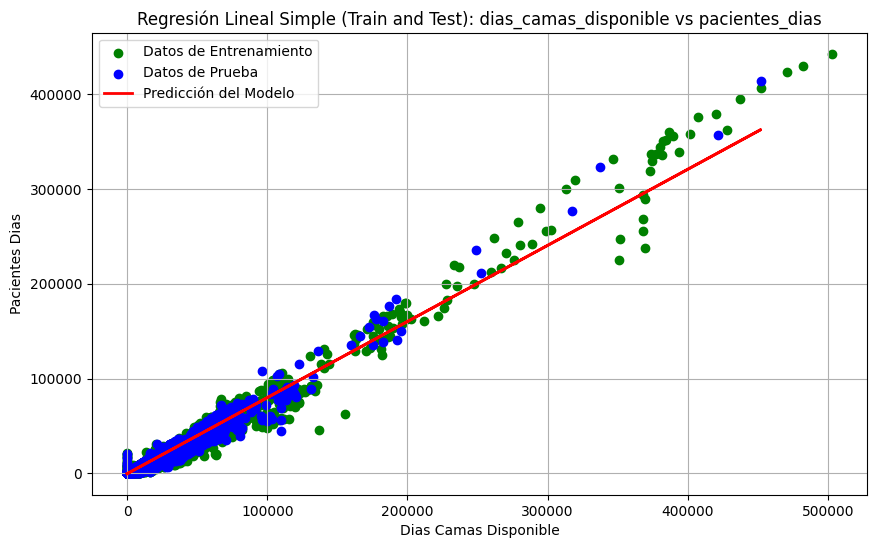

In [50]:
# Visualizar también los datos de entrenamiento
plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color='green', label='Datos de Entrenamiento')
plt.scatter(X_test, y_test, color='blue', label='Datos de Prueba')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicción del Modelo')
plt.title(f'Regresión Lineal Simple (Train and Test): {variable_independiente} vs {variable_dependiente}')
plt.xlabel(variable_independiente.replace("_", " ").title())
plt.ylabel(variable_dependiente.replace("_", " ").title())
plt.legend()
plt.grid(True)
plt.show()

### Rango Intercuartílico (IQR)

Un método común para identificar y eliminar outliers es el método del Rango Intercuartílico (IQR). Este método se basa en los cuartiles de la distribución de los datos. [2]

**Primer Cuartil (Q1):** El valor por debajo del cual cae el 25% de los datos.

**Tercer Cuartil (Q3):** El valor por debajo del cual cae el 75% de los datos.

**Rango Intercuartílico (IQR):** Es la diferencia entre el Tercer Cuartil y el Primer Cuartil (IQR = Q3 - Q1).

Los valores que se consideran outliers según este método son aquellos que caen por debajo de Q1 - 1.5 * IQR o por encima de Q3 + 1.5 * IQR. [2]

In [51]:
# Identificar outliers para 'consultas_odontologicas'
col = 'consultas_odontologicas'
if col in df_final.columns:
    print(f"\nIdentificando outliers para la columna: {col}")
    Q1 = df_final[col].quantile(0.25)
    Q3 = df_final[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_odontologicas = df_final[(df_final[col] < lower_bound) | (df_final[col] > upper_bound)].copy()
    print(f"Número de outliers detectados en '{col}': {len(outliers_odontologicas)}")
    if not outliers_odontologicas.empty:
        print(f"Primeras filas de los outliers en '{col}':")
        display(outliers_odontologicas.head())
else:
    print(f"\nAdvertencia: La columna '{col}' no se encontró en el DataFrame.")


Identificando outliers para la columna: consultas_odontologicas
Número de outliers detectados en 'consultas_odontologicas': 4590
Primeras filas de los outliers en 'consultas_odontologicas':


,anio,region_sanitaria,municipio_id,municipio_nombre,establecimiento_nombre,dependencia,consultas_odontologicas,consultas_medicas,consultas_paramedicas,interconsultas,egresos,dias_camas_disponible,promedio_camas_disponibles,pacientes_dias,porcentaje_ocupacion,dias_estadia,promedio_dias_estadia,defunciones,giro_de_camas,tasa_mortalidad_hospitalaria,dependencia_id,establecimiento_id,tipo_establecimiento
0,2005,I,60007,Adolfo Alsina,Hospital Local General José de San Martín,Municipal,6424,94401,18888,0,1474,10963,30,4798,44,4529,3,42,49,3,1,1,1
1,2005,I,60007,Adolfo Alsina,Hospital Dr. Noe Yarcho,Municipal,4493,18370,4459,0,471,10950,30,2184,20,2027,4,20,16,4,1,2,1
10,2005,I,60014,Adolfo Gonzales Chaves,Hospital Local General A. Elicagaray,Municipal,4852,30725,6975,0,1231,23096,63,17246,75,8800,7,46,20,4,1,11,1
14,2005,I,60056,Bahía Blanca,Hospital Interzonal General Dr. J. Penna,Provincial,12413,158269,11013,0,11142,113690,311,94244,83,82320,7,379,36,3,2,15,1
15,2005,I,60056,Bahía Blanca,Hospital Municipal Dr. Leónidas Lucero,Municipal,5178,212298,5795,0,7472,43303,119,33477,77,30484,4,459,63,6,1,16,1


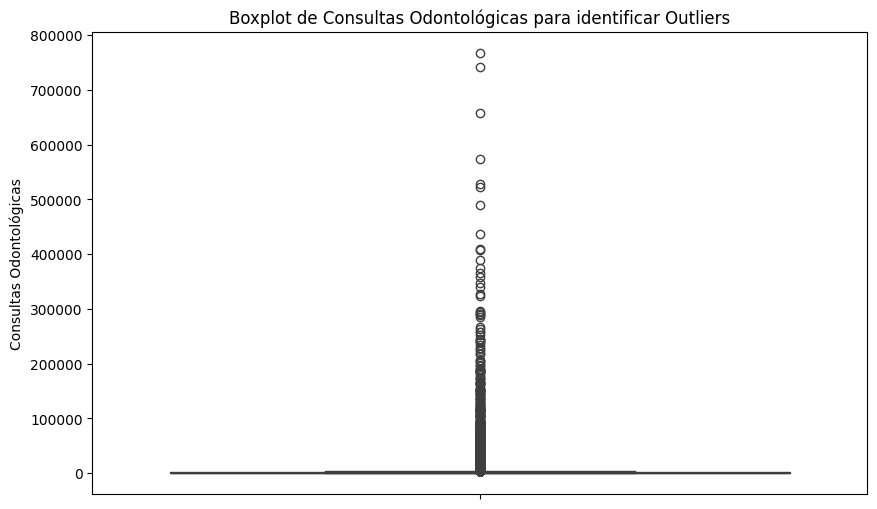

In [52]:
# Crear un boxplot para visualizar la distribución de 'consultas_odontologicas' y los posibles outliers
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_final['consultas_odontologicas'])
plt.title('Boxplot de Consultas Odontológicas para identificar Outliers')
plt.ylabel('Consultas Odontológicas')
plt.show()



Identificación de Outliers por Establecimiento y Año usando IQR:
Total de puntos outliers detectados: 422


,establecimiento_nombre,anio,columna,valor,limite_inferior_IQR,limite_superior_IQR,indice_original
0,Centro Integrador Comunitario (CIC),2014,consultas_odontologicas,389,-145.875,243.125,18928
1,Centro Integrador Comunitario (CIC),2014,consultas_paramedicas,369,-138.375,230.625,18928
2,Centro Integrador Comunitario (CIC),2015,consultas_odontologicas,405,-151.875,253.125,21127
3,Centro Integrador Comunitario (CIC),2015,consultas_paramedicas,262,-98.250,163.750,21127
4,Centro Integrador Comunitario (CIC),2016,consultas_odontologicas,468,-99.000,165.000,23342



Conteo de Outliers por Establecimiento:
establecimiento_nombre
Unidad Sanitaria Nº 3            123
Unid. Sanit. Nº 3                 50
Unidad Sanitaria San Cayetano     30
Unidad Sanitaria Nº 5             28
Unidad Sanitaria Nº 19            17
dtype: int64

Conteo de Outliers por Año:
anio
2005    80
2006    56
2021    25
2017    24
2007    20
dtype: int64

Conteo de Outliers por Columna:
columna
consultas_odontologicas    86
consultas_medicas          80
consultas_paramedicas      72
dias_camas_disponible      23
dias_estadia               23
dtype: int64


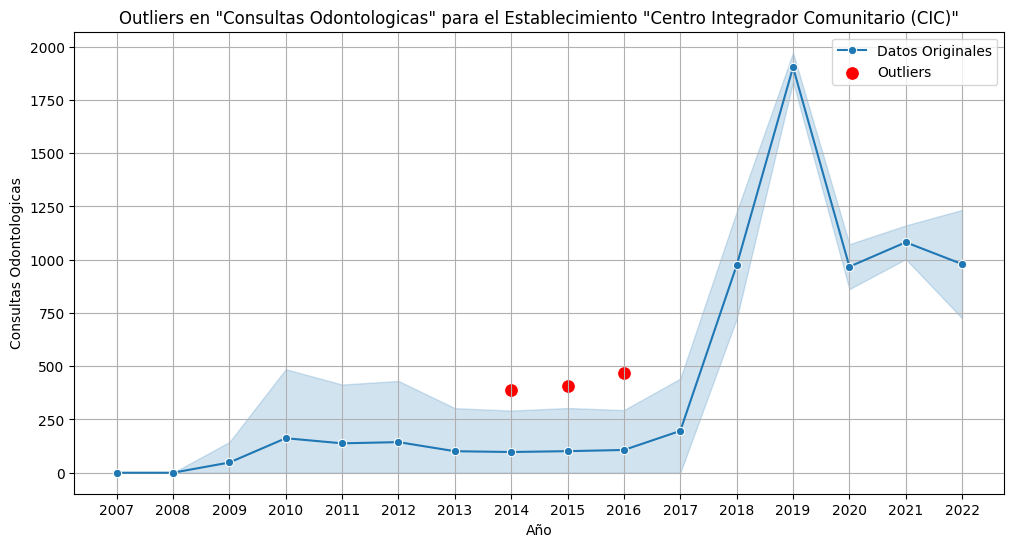

In [53]:
# IDENTIFICAR OUTLIERS por Establecimiento y Año

# Definir las columnas numéricas en las que buscar outliers
cols_to_check_outliers = [
    'consultas_odontologicas',
    'consultas_medicas',
    'consultas_paramedicas',
    'interconsultas',
    'egresos',
    'dias_camas_disponible',
    'promedio_camas_disponibles',
    'pacientes_dias',
    'porcentaje_ocupacion',
    'dias_estadia',
    'promedio_dias_estadia',
    'defunciones',
    'giro_de_camas',
    'tasa_mortalidad_hospitalaria'
]

outliers_list = []

# Iterar sobre cada combinación única de establecimiento_nombre y anio
for (establecimiento, anio), group in df_final.groupby(['establecimiento_nombre', 'anio']):
    # Para cada columna numérica
    for col in cols_to_check_outliers:
        # Asegurarse de que la columna exista y no sea constante (varianza > 0) y tenga suficientes datos
        if col in group.columns and group[col].nunique() > 1 and len(group) > 1:
            Q1 = group[col].quantile(0.25)
            Q3 = group[col].quantile(0.75)
            IQR = Q3 - Q1

            # Definir los límites para los outliers
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Identificar las filas que son outliers para esta columna en este grupo
            outlier_rows = group[(group[col] < lower_bound) | (group[col] > upper_bound)]

            # Agregar la información de los outliers a la lista
            if not outlier_rows.empty:
                for index, row in outlier_rows.iterrows():
                    outliers_list.append({
                        'establecimiento_nombre': establecimiento,
                        'anio': anio,
                        'columna': col,
                        'valor': row[col],
                        'limite_inferior_IQR': lower_bound,
                        'limite_superior_IQR': upper_bound,
                        'indice_original': index # Guardar el índice original si es útil
                    })

# Convertir la lista de outliers a un DataFrame
df_outliers = pd.DataFrame(outliers_list)

# Mostrar el DataFrame de outliers
print("\nIdentificación de Outliers por Establecimiento y Año usando IQR:")
if not df_outliers.empty:
    print(f"Total de puntos outliers detectados: {len(df_outliers)}")
    display(df_outliers.head())
    # Puedes agrupar para ver cuántos outliers hay por establecimiento o año
    print("\nConteo de Outliers por Establecimiento:")
    print(df_outliers.groupby('establecimiento_nombre').size().sort_values(ascending=False).head())
    print("\nConteo de Outliers por Año:")
    print(df_outliers.groupby('anio').size().sort_values(ascending=False).head())
    print("\nConteo de Outliers por Columna:")
    print(df_outliers.groupby('columna').size().sort_values(ascending=False).head())

    # Opcional: Visualizar outliers para una columna específica en el tiempo para un establecimiento particular
    # Elige un establecimiento y una columna para visualizar
    establecimiento_ejemplo = df_outliers['establecimiento_nombre'].iloc[0] if not df_outliers.empty else None
    columna_ejemplo = df_outliers['columna'].iloc[0] if not df_outliers.empty else None

    if establecimiento_ejemplo and columna_ejemplo:
        df_plot_outliers = df_outliers[(df_outliers['establecimiento_nombre'] == establecimiento_ejemplo) & (df_outliers['columna'] == columna_ejemplo)]
        df_plot_original = df_final[(df_final['establecimiento_nombre'] == establecimiento_ejemplo)]

        if not df_plot_outliers.empty:
            plt.figure(figsize=(12, 6))
            # Graficar los datos originales de la columna para ese establecimiento
            sns.lineplot(data=df_plot_original, x='anio', y=columna_ejemplo, marker='o', label='Datos Originales')
            # Graficar los puntos identificados como outliers
            sns.scatterplot(data=df_plot_outliers, x='anio', y='valor', color='red', s=100, label='Outliers')

            plt.title(f'Outliers en "{columna_ejemplo.replace("_", " ").title()}" para el Establecimiento "{establecimiento_ejemplo}"')
            plt.xlabel('Año')
            plt.ylabel(columna_ejemplo.replace("_", " ").title())
            plt.xticks(df_plot_original['anio'].unique())
            plt.grid(True)
            plt.legend()
            plt.show()
else:
    print("No se detectaron outliers significativos por establecimiento y año usando el método IQR.")



## 🔧 Optimización de Hiperparámetros

Este código realiza la optimización de hiperparámetros para modelos de regresión utilizando RandomizedSearchCV en conjunto con Pipelines de preprocesamiento.

El objetivo es encontrar la mejor combinación de configuraciones para cada modelo, mejorando su capacidad predictiva sobre los datos.

Modelos optimizados:
- Decision Tree Regressor
- Random Forest Regressor
- Support Vector Regressor (SVR)
- K-Neighbors Regressor

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# 1. Cargar el archivo desde la URL (tu código actual)
url = 'https://raw.githubusercontent.com/valentinafalco/ProyectoFinal-DS-YPF/refs/heads/main/2da%20Entrega/rendimientos-hospitalarios_2005-2022.csv'
try:
    df = pd.read_csv(url, sep=';', on_bad_lines='skip')
    print("DataFrame cargado exitosamente desde la URL.")
except Exception as e:
    print(f"¡ERROR CRÍTICO al cargar el CSV desde la URL! {e}")
    print("Asegúrate de que la URL sea correcta y accesible.")
    raise # Re-lanza el error para detener la ejecución si falla la carga

# 2. Eliminar columnas con todos los valores NaN 
df_final = df.dropna(axis=1, how='all')
print("Columnas con todos los valores NaN eliminadas.")

# 3. Definimos la variable objetivo (target)
target_variable = 'promedio_dias_estadia' # Asumiendo que este es el nombre correcto en tu CSV

# Verificar que la columna objetivo exista después de la limpieza
if target_variable not in df_final.columns:
    print(f"\n¡ERROR CRÍTICO! La variable objetivo '{target_variable}' no se encontró en el DataFrame df_final.")
    print(f"Columnas disponibles en df_final: {df_final.columns.tolist()}")
    print("Esto puede pasar si la columna objetivo estaba completamente vacía y fue eliminada, o si el nombre es diferente en el CSV.")
    raise ValueError(f"La variable objetivo '{target_variable}' no está disponible.")

# Eliminar filas donde la variable objetivo es NaN ---
initial_rows = df_final.shape[0]
df_final = df_final.dropna(subset=[target_variable])
rows_after_target_nan_drop = df_final.shape[0]
if initial_rows > rows_after_target_nan_drop:
    print(f"¡ATENCIÓN! Se eliminaron {initial_rows - rows_after_target_nan_drop} filas porque la variable objetivo '{target_variable}' contenía valores NaN.")
else:
    print("No se encontraron valores NaN en la variable objetivo. No se eliminaron filas.")

# 4. Separamos features (X) y target (y)
X = df_final.drop(columns=[target_variable])
y = df_final[target_variable]
print(f"X (features) creado con {X.shape[1]} columnas y {X.shape[0]} filas.")
print(f"y (target) creado con {y.shape[0]} filas.")

numeric_features = []
categorical_features = []

for col in X.columns:
    # Si la columna es numérica
    if pd.api.types.is_numeric_dtype(X[col]):
        numeric_features.append(col)
    # Si la columna es de tipo 'object' (strings) o 'category' (categorías)
    elif pd.api.types.is_object_dtype(X[col]) or pd.api.types.is_categorical_dtype(X[col]):
        categorical_features.append(col)
    # Si hay otros tipos de datos que no son ni numéricos ni categóricos típicos
    else:
        print(f"Advertencia: La columna '{col}' tiene un tipo de dato no reconocido para preprocesamiento (ni numérico ni categórico típico): {X[col].dtype}. Será ignorada por los transformadores específicos.")


print("\n--- ¡Columnas detectadas automáticamente para tu preprocesador! ---")
print("Numéricas que se usarán:", numeric_features)
print("Categóricas que se usarán:", categorical_features)
print("------------------------------------------------------------------\n")

# 5. División de los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Datos divididos: X_train={X_train.shape}, y_train={y_train.shape}, X_test={X_test.shape}, y_test={y_test.shape}")

# --- Preprocesamiento de datos 
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')), # Imputa la media para NaNs en numéricas
    ('scaler', StandardScaler()) # Escala las numéricas
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')), # Imputa el valor más frecuente para NaNs en categóricas
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Codifica categóricas a numéricas
])

transformers = []
if numeric_features:
    transformers.append(('num', numeric_transformer, numeric_features))
if categorical_features:
    transformers.append(('cat', categorical_transformer, categorical_features))

# 'remainder='passthrough'' significa que cualquier columna no especificada en numeric_features o categorical_features
# se pasará directamente al modelo sin transformar. Esto es seguro si no esperas otras columnas.
preprocessor = ColumnTransformer(transformers, remainder='passthrough')
print("Preprocesador (ColumnTransformer) creado.")

print("\n--- Iniciando RandomizedSearchCV para DecisionTreeRegressor ---")
pipeline_dt = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', DecisionTreeRegressor(random_state=42))])
param_distributions_dt = {
    'regressor__max_depth': [None, 5, 10, 15, 20],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
}
random_search_dt = RandomizedSearchCV(pipeline_dt,
                                      param_distributions=param_distributions_dt,
                                      n_iter=20,
                                      cv=5,
                                      scoring='neg_mean_squared_error',
                                      random_state=42,
                                      n_jobs=1, # Usamos 1 para evitar problemas de paralelización en entornos limitados
                                      verbose=0) # No mostrar mensajes detallados durante la búsqueda
random_search_dt.fit(X_train, y_train)
print("RandomizedSearchCV para DecisionTreeRegressor completado.")
print(f"Mejor score (neg_mean_squared_error): {random_search_dt.best_score_}")
print(f"Mejores parámetros: {random_search_dt.best_params_}")


print("\n--- Iniciando RandomizedSearchCV para RandomForestRegressor ---")
pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor),
                              ('regressor', RandomForestRegressor(random_state=42))])
param_distributions_rf = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': ['sqrt', 'log2', 1.0]
}
random_search_rf = RandomizedSearchCV(pipeline_rf,
                                      param_distributions=param_distributions_rf,
                                      n_iter=30,
                                      cv=5,
                                      scoring='neg_mean_squared_error',
                                      random_state=42,
                                      n_jobs=1,
                                      verbose=0)
random_search_rf.fit(X_train, y_train)
print("RandomizedSearchCV para RandomForestRegressor completado.")
print(f"Mejor score (neg_mean_squared_error): {random_search_rf.best_score_}")
print(f"Mejores parámetros: {random_search_rf.best_params_}")


print("\n--- Iniciando RandomizedSearchCV para SVR ---")
pipeline_svr = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', SVR())])
param_distributions_svr = {
    'regressor__kernel': ['rbf', 'linear', 'poly'],
    'regressor__C': np.logspace(-1, 2, 4), # Genera [0.1, 1.0, 10.0, 100.0]
    'regressor__epsilon': [0.01, 0.1, 0.2, 0.5],
    'regressor__gamma': ['scale', 'auto']
}
random_search_svr = RandomizedSearchCV(pipeline_svr,
                                       param_distributions=param_distributions_svr,
                                       n_iter=20,
                                       cv=3, # Se usa 3 CV para SVR, es más lento
                                       scoring='neg_mean_squared_error',
                                       random_state=42,
                                       n_jobs=1,
                                       verbose=0)
random_search_svr.fit(X_train, y_train)
print("RandomizedSearchCV para SVR completado.")
print(f"Mejor score (neg_mean_squared_error): {random_search_svr.best_score_}")
print(f"Mejores parámetros: {random_search_svr.best_params_}")


print("\n--- Iniciando RandomizedSearchCV para KNeighborsRegressor ---")
pipeline_knn = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', KNeighborsRegressor())])
param_distributions_knn = {
    'regressor__n_neighbors': np.arange(3, 16), # Números enteros de 3 a 15
    'regressor__weights': ['uniform', 'distance'],
    'regressor__metric': ['euclidean', 'manhattan']
}
random_search_knn = RandomizedSearchCV(pipeline_knn,
                                       param_distributions=param_distributions_knn,
                                       n_iter=20,
                                       cv=5,
                                       scoring='neg_mean_squared_error',
                                       random_state=42,
                                       n_jobs=1,
                                       verbose=0)
random_search_knn.fit(X_train, y_train)
print("RandomizedSearchCV para KNeighborsRegressor completado.")
print(f"Mejor score (neg_mean_squared_error): {random_search_knn.best_score_}")
print(f"Mejores parámetros: {random_search_knn.best_params_}")

print("\n--- ¡Todos los modelos han sido entrenados y optimizados! ---")
# acceder a los mejores modelos así:
# best_dt_model = random_search_dt.best_estimator_
# best_rf_model = random_search_rf.best_estimator_
# best_svr_model = random_search_svr.best_estimator_
# best_knn_model = random_search_knn.best_estimator_

DataFrame cargado exitosamente desde la URL.
Columnas con todos los valores NaN eliminadas.
¡ATENCIÓN! Se eliminaron 9663 filas porque la variable objetivo 'promedio_dias_estadia' contenía valores NaN.
X (features) creado con 20 columnas y 29330 filas.
y (target) creado con 29330 filas.

--- ¡Columnas detectadas automáticamente para tu preprocesador! ---
Numéricas que se usarán: ['anio', 'municipio_id', 'establecimiento_id', 'consultas_odontologicas', 'consultas_medicas', 'consultas_paramedicas', 'interconsultas', 'egresos', 'dias_camas_disponible', 'promedio_camas_disponibles', 'pacientes_dias', 'porcentaje_ocupacion', 'dias_estadia', 'defunciones', 'giro_de_camas', 'tasa_mortalidad_hospitalaria']
Categóricas que se usarán: ['region_sanitaria', 'municipio_nombre', 'establecimiento_nombre', 'dependencia']
------------------------------------------------------------------

Datos divididos: X_train=(23464, 20), y_train=(23464,), X_test=(5866, 20), y_test=(5866,)
Preprocesador (ColumnTran

## ✅ Conclusiones

- Se aplicó un modelo de aprendizaje supervisado utilizando Random Forest para clasificar el rendimiento de los hospitales.
- La evaluación del modelo mostró un buen desempeño en términos de precisión y recall.
- Mediante la optimización de hiperparámetros, se logró mejorar aún más la capacidad predictiva del modelo.
- Este análisis permite tomar decisiones basadas en datos sobre el funcionamiento de los establecimientos de salud.

---

> 💡 Este proyecto demuestra cómo el análisis de datos y el machine learning pueden aplicarse al ámbito de la salud pública para obtener información valiosa y orientar políticas públicas.
